# Investment Analysis Lecture: Returns, Risk, Valuation, and Performance Measurement

These notes build from first principles. A student should be able to move from the basic definition of a return, to the economic origin of required returns, to practical return measurement, to statistical and downside risk analysis, and finally to rolling-window and fractal diagnostics used in applied investment work.

The lecture sequence is:

1. What a return is: income, capital gains, and holding-period returns.
2. Where returns come from: firm profits, investor preferences, and equilibrium discounting.
3. How returns are measured through compounding, inflation, taxes, and annualization.
4. How return distributions are summarized using moments and empirical frequencies.
5. How risk is measured beyond variance, including downside and tail-risk measures.
6. How practitioners use rolling windows, moving moments, and diagnostics such as the Hurst exponent.
7. How expected returns become the firm's cost of equity and a hurdle rate for capital budgeting.


## Notebook Setup

The code examples use only standard scientific Python libraries. The demonstrations are deliberately small and self-contained so that the notebook can be run without downloading outside data.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Part I. What Returns Are

A return is the compensation earned for committing capital over time. In ordinary investment language, the return combines cash income and price appreciation. In economic language, the return is the reward required to move resources from the present into a risky future.


## 1. The Basic Question

Investment analysis begins with a simple question:

> If I give up resources today, what compensation do I require in the future?

That compensation is a **return**. But the return is not merely a mechanical number. It reflects time, risk, inflation, taxation, and equilibrium pricing. At the deepest level, the required return on an investment is determined by the preferences and opportunities of investors. Firms then take that required return as their **cost of capital** and use it as a hurdle rate when deciding whether to invest.

The logic of the lecture is:

1. Firms generate cash flows from production.
2. Investors value those cash flows by discounting them.
3. The discount rate comes from equilibrium investor preferences.
4. Expected returns depend on risk, especially covariance with the stochastic discount factor.
5. Return measurement requires careful treatment of compounding, inflation, taxes, and statistical risk.

---

## 2. Total Return: Income Plus Capital Gain

Now turn to return measurement.

The **total return** on an asset has two components:

1. Income return
2. Capital gain return

Suppose an asset has initial price $ P_0 $, ending price $ P_1 $, and pays income $ D_1 $, such as a dividend, coupon, or rent.

The holding-period return is:

$$
R = \frac{P_1 + D_1 - P_0}{P_0}
$$

This can be decomposed as:

$$
R = \frac{D_1}{P_0} + \frac{P_1 - P_0}{P_0}
$$

The first term is the income component:

$$
\frac{D_1}{P_0}
$$

The second term is the capital gain component:

$$
\frac{P_1 - P_0}{P_0}
$$

So:

$$
\boxed{
\text{Total return}
=
\text{Income return}
+
\text{Capital gain return}
}
$$

Example:

A stock begins the year at $ \$100 $, pays a $ \$3 $ dividend, and ends the year at $ \$108 $.

The income return is:

$$
\frac{3}{100} = 0.03 = 3\%
$$

The capital gain return is:

$$
\frac{108-100}{100} = 0.08 = 8\%
$$

The total return is:

$$
0.03 + 0.08 = 0.11 = 11\%
$$

---

## 3. Holding-Period Returns

A **holding-period return** is the return earned over the actual period during which the asset is held.

The formula is:

$$
HPR = \frac{\text{Ending value} + \text{Income} - \text{Beginning value}}{\text{Beginning value}}
$$

Or, as a gross return:

$$
1+HPR = \frac{\text{Ending value} + \text{Income}}{\text{Beginning value}}
$$

If an asset is purchased for $ \$50 $, pays a $ \$2 $ dividend, and is sold for $ \$55 $, then:

$$
HPR = \frac{55 + 2 - 50}{50}
$$

$$
HPR = \frac{7}{50} = 0.14 = 14\%
$$

The gross return is:

$$
1+HPR = 1.14
$$

Holding-period returns are useful because they directly measure what happened over the investor’s actual holding period.

However, they are not always directly comparable across investments with different holding periods. A 10% return over one month is not the same as a 10% return over five years.

That is why we annualize returns.

---

### Python Demonstration: Total Return and Holding-Period Return

The following example decomposes total return into its income and capital-gain components. The same calculation works for stocks, bonds, real estate, commodities with convenience yield, and any other asset with an initial price, terminal price, and interim income.

In [2]:
assets = pd.DataFrame({
    "Asset": ["Dividend stock", "Coupon bond", "No-income growth stock"],
    "Beginning Price": [100.00, 1_000.00, 50.00],
    "Ending Price": [108.00, 980.00, 65.00],
    "Income": [3.00, 50.00, 0.00]
})

assets["Income Return"] = assets["Income"] / assets["Beginning Price"]
assets["Capital Gain Return"] = (assets["Ending Price"] - assets["Beginning Price"]) / assets["Beginning Price"]
assets["Total HPR"] = assets["Income Return"] + assets["Capital Gain Return"]
assets["Gross Return"] = 1 + assets["Total HPR"]

assets

,Asset,Beginning Price,Ending Price,Income,Income Return,Capital Gain Return,Total HPR,Gross Return
0,Dividend stock,100.0000,108.0000,3.0000,0.0300,0.0800,0.1100,1.1100
1,Coupon bond,"1,000.0000",980.0000,50.0000,0.0500,-0.0200,0.0300,1.0300
2,No-income growth stock,50.0000,65.0000,0.0000,0.0000,0.3000,0.3000,1.3000


## 4. From Single Returns to a Return Series

Once the holding-period return is defined, we can treat a sequence of monthly, quarterly, or annual returns as data. The simulated example below gives students a return series with ordinary months and occasional crash months. It will be reused throughout the notebook to illustrate averages, volatility, drawdowns, rolling windows, tail events, and performance ratios.


### Python Demonstration: Simulating a Return Series

Before introducing the formal statistics, it is useful to give students a concrete return series to work with. The next cell simulates monthly returns for a risky portfolio. The distribution is deliberately not perfectly normal: most months are ordinary, but a small number of months are crash-like. That gives us a series with negative skewness and fat tails, which is closer to many real financial return series than a textbook normal distribution.

In [3]:
# Simulate a monthly return series with ordinary months and occasional crash months.
rng = np.random.default_rng(2026)
n_months = 240
months = pd.period_range("2006-01", periods=n_months, freq="M").to_timestamp()

ordinary_month = rng.normal(loc=0.008, scale=0.035, size=n_months)
crash_month = rng.normal(loc=-0.14, scale=0.07, size=n_months)
crash_indicator = rng.binomial(n=1, p=0.055, size=n_months).astype(bool)

simulated_returns = pd.Series(
    np.where(crash_indicator, crash_month, ordinary_month),
    index=months,
    name="Simulated Monthly Return"
)

simulated_returns.head(12).to_frame()


,Simulated Monthly Return
2006-01-01,-0.0198
2006-02-01,0.0164
2006-03-01,-0.0584
2006-04-01,0.0569
2006-05-01,0.0303
2006-06-01,-0.0022
2006-07-01,-0.0029
2006-08-01,0.0186
2006-09-01,-0.0014
2006-10-01,0.0001


### Python Demonstration: Wealth Index, Cumulative Return, and Drawdown

A return series becomes easier to interpret when translated into a wealth index. If an investor starts with $1, the wealth path after returns $R_1, R_2, \ldots, R_T$ is:

$$
W_T = \prod_{t=1}^{T}(1+R_t)
$$

The drawdown compares current wealth with the previous running maximum.

In [4]:
# Convert returns into a wealth index and drawdown series.
wealth_index = (1 + simulated_returns).cumprod()
running_peak = wealth_index.cummax()
drawdown_series = wealth_index / running_peak - 1

wealth_summary = pd.DataFrame({
    "Ending wealth from $1": [wealth_index.iloc[-1]],
    "Total cumulative return": [wealth_index.iloc[-1] - 1],
    "Worst drawdown": [drawdown_series.min()],
    "Best monthly return": [simulated_returns.max()],
    "Worst monthly return": [simulated_returns.min()]
})
wealth_summary.applymap(lambda x: f"{x:.2%}" if abs(x) < 10 else f"{x:.2f}")


/tmp/ipykernel_5818/3892594265.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  wealth_summary.applymap(lambda x: f"{x:.2%}" if abs(x) < 10 else f"{x:.2f}")


,Ending wealth from $1,Total cumulative return,Worst drawdown,Best monthly return,Worst monthly return
0,40.33%,-59.67%,-68.95%,11.83%,-27.17%


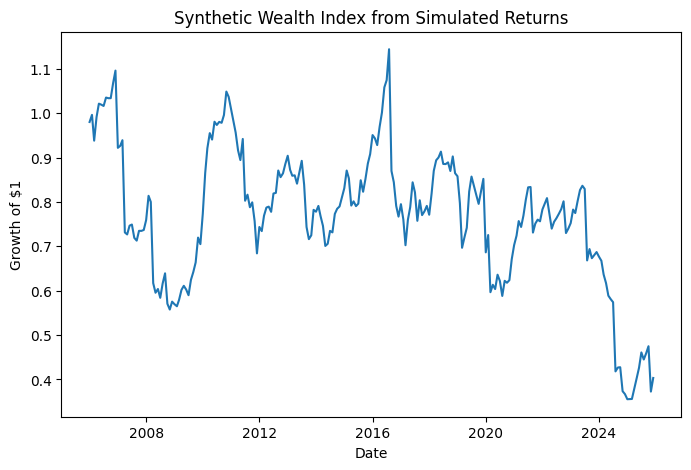

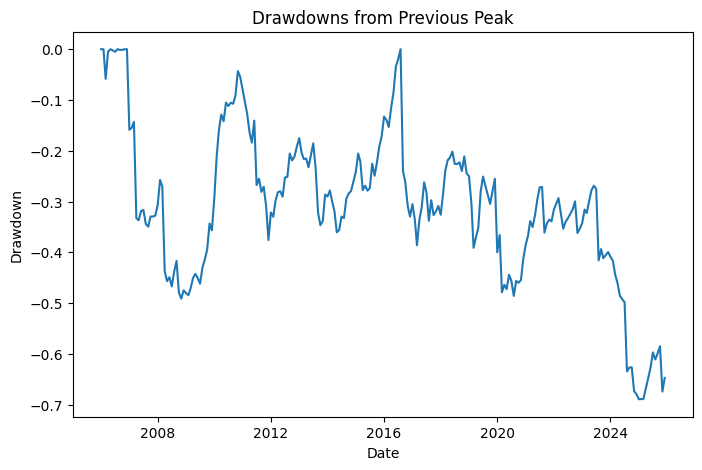

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(wealth_index.index, wealth_index.values)
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.title("Synthetic Wealth Index from Simulated Returns")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(drawdown_series.index, drawdown_series.values)
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.title("Drawdowns from Previous Peak")
plt.show()


# Part II. Where Returns Come From: Firms, Investors, and Equilibrium

The previous section defined returns mechanically. This section explains why required returns exist. Firms produce risky profits. Investors value those profits using marginal utility. The equilibrium required return is therefore tied to time preference, risk, and the covariance of payoffs with bad states of the world.


## 5. The Firm in a Competitive Market

Begin with a firm operating in a competitive product market.

Let the firm produce output $ q $. The market price of output is $ P $. Because the firm is competitive, it takes $ P $ as given.

The firm has a cost function:

$$
C(q)
$$

Profit is:

$$
\pi(q) = Pq - C(q)
$$

The firm chooses output to maximize profit:

$$
\max_q \; Pq - C(q)
$$

The first-order condition is:

$$
P = C'(q)
$$

That is:

$$
P = MC(q)
$$

The competitive firm produces until price equals marginal cost.

Total profit at the optimal output $ q^* $ is:

$$
\pi^* = Pq^* - C(q^*)
$$

Graphically, if price exceeds average total cost, the firm earns positive economic profit. If price equals average total cost, profit is zero. If price is below average total cost but above average variable cost, the firm may operate in the short run while losing money.

---

## 6. A Two-Period Firm Valuation Model

Now suppose the firm operates in a simple two-period world.

At date $ t=0 $, investors buy claims to the firm.

At date $ t=1 $, the firm produces, sells output, pays costs, and distributes profit to shareholders.

Let the firm’s date-1 profit be:

$$
\pi_1
$$

If the relevant required return is $ r $, then the date-0 market value of equity is:

$$
E_0 = \frac{\pi_1}{1+r}
$$

If date-1 profit is uncertain, the expression becomes:

$$
E_0 = \frac{\mathbb{E}_0[\pi_1]}{1+r}
$$

but that formulation is incomplete unless the profit is riskless. For risky profit, the correct valuation is not simply expected profit divided by a single risk-free discount rate. Risk matters.

The more general valuation formula is:

$$
E_0 = \mathbb{E}_0[M_1 \pi_1]
$$

where $ M_1 $ is the **stochastic discount factor**.

This equation says:

> A payoff is valuable today if it pays off in states of the world where investors value consumption highly.

That is the central microfoundation of investment analysis.

---

## 7. Where Does the Discount Rate Come From?

In a basic finance class, we often write:

$$
PV = \frac{CF_1}{1+r}
$$

But this leaves open a deeper question:

> Where does the discount rate $ r $ come from?

It is not arbitrary. It is determined in equilibrium by investors’ preferences over consumption today versus consumption tomorrow, and by the riskiness of future payoffs.

To see this, use a simple Lucas tree model.

---

## 8. A Simple Lucas Tree Economy

Imagine an economy with one representative investor and one asset: a tree.

The tree produces fruit each period. Fruit is the consumption good.

At date $ t=0 $, the investor consumes $ C_0 $.

At date $ t=1 $, the tree produces a random dividend $ D_1 $, and the investor consumes $ C_1 $.

The investor has expected lifetime utility:

$$
U = u(C_0) + \beta \mathbb{E}_0[u(C_1)]
$$

where:

- $ u(C) $ is the utility function,
- $ u'(C) > 0 $: more consumption is preferred to less,
- $ u''(C) < 0 $: marginal utility declines as consumption rises,
- $ \beta \in (0,1) $ is the subjective discount factor.

No special functional form is required. We do not need logarithmic utility, CRRA utility, or quadratic utility. The key object is the ratio of marginal utilities.

Suppose the investor can buy an asset with price $ P_0 $ that pays payoff $ X_1 $ next period.

The investor chooses how much of the asset to buy. The first-order condition implies:

$$
P_0 u'(C_0) = \beta \mathbb{E}_0[u'(C_1) X_1]
$$

Divide both sides by $ u'(C_0) $:

$$
P_0 = \mathbb{E}_0 \left[ \beta \frac{u'(C_1)}{u'(C_0)} X_1 \right]
$$

Define the stochastic discount factor:

$$
M_1 = \beta \frac{u'(C_1)}{u'(C_0)}
$$

Then:

$$
P_0 = \mathbb{E}_0[M_1 X_1]
$$

This is the fundamental asset-pricing equation.

---

## 9. Interpretation of the Stochastic Discount Factor

The stochastic discount factor is:

$$
M_1 = \beta \frac{u'(C_1)}{u'(C_0)}
$$

It is high when future marginal utility is high.

Future marginal utility is high when future consumption is low. Therefore, payoffs that occur in bad states are especially valuable.

A payoff that arrives during a recession, crisis, or low-consumption state provides insurance. Investors value it highly.

A payoff that arrives mainly in boom states is less valuable, because investors already have high consumption in those states.

This is why risk is not merely variance. What matters is **covariance with marginal utility**.

---

## 10. Returns and the Asset-Pricing Equation

Let an asset have price $ P_0 $ and payoff $ X_1 $. Its gross return is:

$$
R_1 = \frac{X_1}{P_0}
$$

Using:

$$
P_0 = \mathbb{E}_0[M_1 X_1]
$$

divide both sides by $ P_0 $:

$$
1 = \mathbb{E}_0[M_1 R_1]
$$

This is the central return-pricing equation:

$$
\boxed{1 = \mathbb{E}_0[M_1 R_1]}
$$

Using the identity:

$$
\mathbb{E}[MR] = \mathbb{E}[M]\mathbb{E}[R] + \operatorname{Cov}(M,R)
$$

we get:

$$
1 = \mathbb{E}[M]\mathbb{E}[R] + \operatorname{Cov}(M,R)
$$

So:

$$
\mathbb{E}[R] = \frac{1 - \operatorname{Cov}(M,R)}{\mathbb{E}[M]}
$$

For the risk-free asset, $ R_f $ is known in advance. Therefore:

$$
1 = \mathbb{E}[M]R_f
$$

so:

$$
R_f = \frac{1}{\mathbb{E}[M]}
$$

Substitute into the expected return equation:

$$
\mathbb{E}[R] = R_f - R_f \operatorname{Cov}(M,R)
$$

Therefore, the expected excess return is:

$$
\mathbb{E}[R] - R_f = -R_f \operatorname{Cov}(M,R)
$$

This is one of the most important results in asset pricing.

If an asset has a **negative covariance** with the stochastic discount factor, it pays off poorly when marginal utility is high. In other words, it performs badly in bad times. Investors dislike this risk and demand a higher expected return.

If an asset has a **positive covariance** with the stochastic discount factor, it pays off well in bad times. It provides insurance, so investors accept a lower expected return.

---

## 11. Probability Concepts and the Investor's Problem

The probability concepts are not merely descriptive statistics. They matter because investors choose portfolios under uncertainty.

An investor does not care only about the expected return of an asset. The investor cares about how the asset affects lifetime utility.

Recall the asset-pricing condition:

$$
1 = \mathbb{E}[M R]
$$

Using covariance:

$$
1 = \mathbb{E}[M]\mathbb{E}[R] + \operatorname{Cov}(M,R)
$$

This equation connects probability directly to equilibrium expected returns.

The expected return of an asset depends on:

1. The average payoff.
2. The timing of the payoff across states.
3. The covariance of the payoff with marginal utility.
4. The investor’s willingness to substitute consumption across time and states.

Standard deviation alone is not enough.

An asset can have high variance but still be valuable if it pays off in bad states.

An asset can have modest variance but command a high expected return if it fails exactly when investors most need wealth.

This is why covariance is the central risk concept in modern asset pricing.

---

## 12. A Simple Numerical SDF Example

Suppose there are two states next period:

| State | Probability | Consumption | Marginal Utility | SDF $M$ |
|---|---:|---:|---:|---:|
| Good | 0.5 | High | Low | 0.80 |
| Bad | 0.5 | Low | High | 1.20 |

The stochastic discount factor is high in the bad state because marginal utility is high.

Consider two assets.

### Asset A: Procyclical Equity

| State | Return |
|---|---:|
| Good | 20% |
| Bad | -5% |

Gross returns are:

| State | Gross Return |
|---|---:|
| Good | 1.20 |
| Bad | 0.95 |

Compute:

$$
\mathbb{E}[M R_A]
=
0.5(0.80)(1.20)
+
0.5(1.20)(0.95)
$$

$$
=
0.48 + 0.57
$$

$$
= 1.05
$$

If $ \mathbb{E}[MR] > 1 $, the asset is too cheap relative to equilibrium, or its expected return is too high for its risk. In equilibrium, its price would be bid up until:

$$
\mathbb{E}[MR] = 1
$$

The important point is that this asset pays more in good states and less in bad states. That makes it risky in the economically relevant sense.

### Asset B: Insurance-Like Asset

| State | Return |
|---|---:|
| Good | 0% |
| Bad | 10% |

Gross returns:

| State | Gross Return |
|---|---:|
| Good | 1.00 |
| Bad | 1.10 |

Compute:

$$
\mathbb{E}[M R_B]
=
0.5(0.80)(1.00)
+
0.5(1.20)(1.10)
$$

$$
=
0.40 + 0.66
$$

$$
= 1.06
$$

This asset is valuable because it pays well when the stochastic discount factor is high. Investors would accept a relatively low expected return on this asset because it provides insurance.

The broader lesson:

> Expected returns compensate investors for bearing bad-state risk, not merely for accepting volatility.

---

### Python Demonstration: SDF Covariance and Expected Returns

The following example shows how the same expected payoff can have different value depending on whether it arrives in high-marginal-utility states or low-marginal-utility states.

In [6]:
sdf_example = pd.DataFrame({
    "State": ["Good", "Bad"],
    "Probability": [0.5, 0.5],
    "SDF": [0.80, 1.20],
    "Procyclical Equity Gross Return": [1.20, 0.95],
    "Insurance-Like Gross Return": [1.00, 1.10]
})

for col in ["Procyclical Equity Gross Return", "Insurance-Like Gross Return"]:
    sdf_example[f"M x {col}"] = sdf_example["SDF"] * sdf_example[col]

summary = []
for col in ["Procyclical Equity Gross Return", "Insurance-Like Gross Return"]:
    expected_gross_return = (sdf_example["Probability"] * sdf_example[col]).sum()
    expected_mr = (sdf_example["Probability"] * sdf_example["SDF"] * sdf_example[col]).sum()
    covariance = (sdf_example["Probability"] * (sdf_example["SDF"] - (sdf_example["Probability"] * sdf_example["SDF"]).sum()) * (sdf_example[col] - expected_gross_return)).sum()
    summary.append([col, expected_gross_return, expected_mr, covariance])

pd.DataFrame(summary, columns=["Asset", "Expected Gross Return", "E[M R]", "Cov(M,R)"])

,Asset,Expected Gross Return,E[M R],"Cov(M,R)"
0,Procyclical Equity Gross Return,1.0750,1.0500,-0.0250
1,Insurance-Like Gross Return,1.0500,1.0600,0.0100


## 13. Connecting This to the Firm's Cost of Equity

A firm’s equity is a claim on its future profits:

$$
X_1 = \pi_1
$$

Therefore:

$$
E_0 = \mathbb{E}_0[M_1 \pi_1]
$$

The expected return on the firm’s equity is:

$$
\mathbb{E}[R_E]
$$

This expected return is the firm’s **cost of equity**.

Why?

Because shareholders require compensation for holding the firm’s risky profits. If the firm wants to raise equity capital, it must offer investors an expected return high enough to persuade them to hold its shares.

The firm’s cost of equity is not determined by management preference. It is determined in capital-market equilibrium by investors’ valuation of the firm’s risk.

A firm whose profits are high in booms and low in recessions will generally have a high cost of equity because its profits covary negatively with the stochastic discount factor.

A firm whose profits are stable or countercyclical will generally have a lower cost of equity.

---

## 14. Cost of Equity as a Capital Budgeting Hurdle Rate

Suppose the firm is considering an investment project.

The project costs $ I_0 $ today and produces expected future cash flow $ CF_1 $.

The project should be accepted if its net present value is positive:

$$
NPV = -I_0 + PV(CF_1)
$$

If the project has the same risk as the firm’s existing equity, then the firm may discount using its cost of equity:

$$
NPV = -I_0 + \frac{\mathbb{E}[CF_1]}{1+r_E}
$$

Accept the project if:

$$
NPV > 0
$$

Equivalently, accept if the project’s expected return exceeds the cost of equity:

$$
\mathbb{E}[R_{\text{project}}] > r_E
$$

The cost of equity is therefore a **hurdle rate**.

However, the correct hurdle rate depends on project risk, not merely firm identity. A safe project should not be discounted at the same rate as a highly cyclical project. The discount rate should reflect the project’s covariance with the stochastic discount factor.

The theoretically correct valuation is:

$$
PV = \mathbb{E}[M_1 CF_1]
$$

The common textbook discount-rate approach is a simplified version of this deeper principle.

---

# Part III. Measuring Returns Through Time

Now that returns have been defined and micro-founded, we need the measurement conventions used in finance. This includes compounding, continuously compounded returns, real versus nominal rates, taxes, and the distinction between arithmetic and geometric averages.


## 15. Annual Percentage Rate and Effective Annual Rate

The **annual percentage rate**, or APR, is a quoted annual rate that does not fully incorporate the effect of compounding within the year.

The **effective annual rate**, or EAR, is the actual annual rate earned after accounting for compounding.

If the APR is $ r_{\text{APR}} $, and compounding occurs $ m $ times per year, then:

$$
EAR = \left(1 + \frac{r_{\text{APR}}}{m}\right)^m - 1
$$

For example, if the APR is 12% and interest is compounded monthly, then:

$$
EAR = \left(1 + \frac{0.12}{12}\right)^{12} - 1
$$

$$
EAR = (1.01)^{12} - 1
$$

$$
EAR \approx 0.1268 = 12.68\%
$$

So a 12% APR compounded monthly is not actually a 12% annual return. It is a 12.68% effective annual return.

The more frequently interest compounds, the higher the effective annual rate, holding the APR fixed.

---

## 16. Continuous Compounding

As compounding becomes more frequent, the compounding interval becomes smaller. In the limit, we get **continuous compounding**.

If $ r_c $ is the continuously compounded annual rate, then the future value of $ PV $ after $ T $ years is:

$$
FV = PV e^{r_c T}
$$

The present value of $ FV $ received $ T $ years from now is:

$$
PV = FV e^{-r_c T}
$$

The relationship between an effective annual rate $ EAR $ and a continuously compounded rate $ r_c $ is:

$$
1 + EAR = e^{r_c}
$$

Therefore:

$$
r_c = \ln(1+EAR)
$$

and:

$$
EAR = e^{r_c} - 1
$$

Example:

If the effective annual rate is 10%, then the continuously compounded rate is:

$$
r_c = \ln(1.10)
$$

$$
r_c \approx 0.09531 = 9.531\%
$$

If the continuously compounded rate is 9.531%, then:

$$
EAR = e^{0.09531} - 1 \approx 0.10 = 10\%
$$

Continuously compounded returns are especially useful in theory because log returns add across time.

If the price of an asset changes from $ P_0 $ to $ P_1 $, the continuously compounded return is:

$$
r = \ln\left(\frac{P_1}{P_0}\right)
$$

If the asset then moves from $ P_1 $ to $ P_2 $, the second continuously compounded return is:

$$
r_2 = \ln\left(\frac{P_2}{P_1}\right)
$$

The two-period continuously compounded return is:

$$
\ln\left(\frac{P_2}{P_0}\right)
$$

and:

$$
\ln\left(\frac{P_2}{P_0}\right)
=
\ln\left(\frac{P_1}{P_0}\right)
+
\ln\left(\frac{P_2}{P_1}\right)
$$

So log returns are time-additive.

---

## 17. Worked Example: The Effects of Compounding

Suppose an investor places $ \$10,000 $ in an account with a quoted APR of 8%.

Compare annual, quarterly, monthly, daily, and continuous compounding over 10 years.

The general formula is:

$$
FV = PV \left(1 + \frac{r}{m}\right)^{mT}
$$

where:

- $ PV = 10{,}000 $,
- $ r = 0.08 $,
- $ T = 10 $,
- $ m $ is the number of compounding periods per year.

### Annual Compounding

$$
FV = 10{,}000(1.08)^{10}
$$

$$
FV \approx 10{,}000(2.1589)
$$

$$
FV \approx 21{,}589
$$

### Quarterly Compounding

$$
FV = 10{,}000\left(1+\frac{0.08}{4}\right)^{40}
$$

$$
FV = 10{,}000(1.02)^{40}
$$

$$
FV \approx 22{,}080
$$

### Monthly Compounding

$$
FV = 10{,}000\left(1+\frac{0.08}{12}\right)^{120}
$$

$$
FV \approx 22{,}196
$$

### Daily Compounding

$$
FV = 10{,}000\left(1+\frac{0.08}{365}\right)^{3650}
$$

$$
FV \approx 22{,}251
$$

### Continuous Compounding

$$
FV = 10{,}000e^{0.08(10)}
$$

$$
FV = 10{,}000e^{0.8}
$$

$$
FV \approx 22{,}255
$$

The results are:

| Compounding Frequency | Future Value |
|---:|---:|
| Annual | \$21,589 |
| Quarterly | \$22,080 |
| Monthly | \$22,196 |
| Daily | \$22,251 |
| Continuous | \$22,255 |

The lesson is:

> More frequent compounding increases wealth, but the gains become smaller as compounding frequency rises.

The jump from annual to quarterly compounding is meaningful. The jump from daily to continuous compounding is tiny.

---

### Python Demonstration: Compounding Frequency

The next cell reproduces the compounding example and shows why the gain from more frequent compounding eventually becomes very small. Continuous compounding is the limiting case.

In [7]:
pv = 10_000
apr = 0.08
years = 10
frequencies = {
    "Annual": 1,
    "Quarterly": 4,
    "Monthly": 12,
    "Daily": 365
}

rows = []
for name, m in frequencies.items():
    fv = pv * (1 + apr / m) ** (m * years)
    ear = (1 + apr / m) ** m - 1
    rows.append([name, m, ear, fv])

rows.append(["Continuous", math.inf, math.exp(apr) - 1, pv * math.exp(apr * years)])
compounding = pd.DataFrame(rows, columns=["Compounding", "Periods per Year", "Effective Annual Rate", "Future Value"])
compounding

,Compounding,Periods per Year,Effective Annual Rate,Future Value
0,Annual,1.0000,0.0800,"21,589.2500"
1,Quarterly,4.0000,0.0824,"22,080.3966"
2,Monthly,12.0000,0.0830,"22,196.4023"
3,Daily,365.0000,0.0833,"22,253.4585"
4,Continuous,inf,0.0833,"22,255.4093"


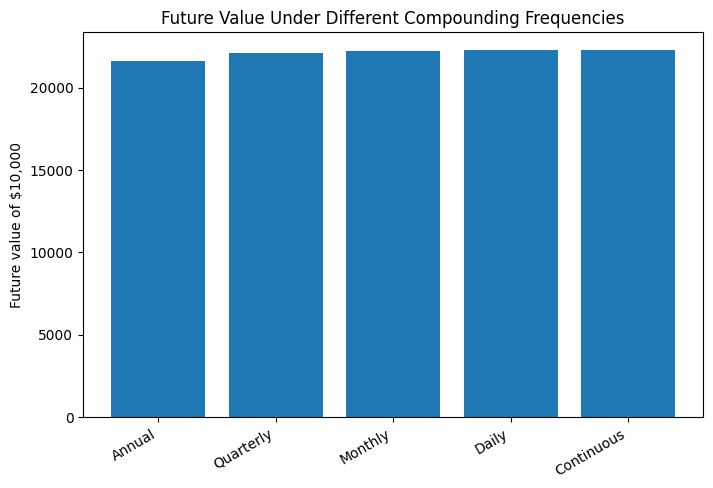

In [8]:
plot_data = compounding.replace({math.inf: np.nan}).copy()
plt.figure(figsize=(8, 5))
plt.bar(plot_data["Compounding"], plot_data["Future Value"])
plt.ylabel("Future value of $10,000")
plt.title("Future Value Under Different Compounding Frequencies")
plt.xticks(rotation=30, ha="right")
plt.show()

## 18. Nominal and Real Interest Rates

A **nominal interest rate** measures the percentage increase in dollars.

A **real interest rate** measures the percentage increase in purchasing power.

If an investment earns 8% but prices rise by 3%, the investor’s purchasing power does not rise by the full 8%.

Let:

- $ i $ be the nominal interest rate,
- $ r $ be the real interest rate,
- $ \pi $ be the inflation rate.

The exact relationship is:

$$
1+i = (1+r)(1+\pi)
$$

Solving for the real interest rate:

$$
1+r = \frac{1+i}{1+\pi}
$$

$$
r = \frac{1+i}{1+\pi} - 1
$$

Example:

If the nominal rate is 8% and inflation is 3%, then:

$$
r = \frac{1.08}{1.03} - 1
$$

$$
r \approx 0.0485 = 4.85\%
$$

The approximate relationship is:

$$
i \approx r + \pi
$$

So:

$$
r \approx i - \pi
$$

Using the approximation:

$$
r \approx 8\% - 3\% = 5\%
$$

The approximation is close, but not exact.

---

## 19. The Fisher Equation

The Fisher equation relates nominal interest rates, real interest rates, and expected inflation.

The exact Fisher equation is:

$$
1+i = (1+r)(1+\mathbb{E}[\pi])
$$

The approximate Fisher equation is:

$$
i \approx r + \mathbb{E}[\pi]
$$

where $ \mathbb{E}[\pi] $ is expected inflation.

The Fisher equation says that nominal rates compensate investors for two things:

1. The real return required for postponing consumption.
2. Expected loss of purchasing power due to inflation.

If expected inflation rises while the real rate is unchanged, nominal interest rates should rise.

---

## 20. The Fisher Hypothesis

The **Fisher hypothesis** is the proposition that nominal interest rates adjust one-for-one with expected inflation, leaving real interest rates unchanged.

If expected inflation rises by 1 percentage point, nominal interest rates should rise by approximately 1 percentage point.

Formally:

$$
\Delta i \approx \Delta \mathbb{E}[\pi]
$$

if the real rate $ r $ is constant.

The Fisher hypothesis is an equilibrium claim. It assumes that investors care about real purchasing power, not merely dollar payoffs.

If lenders expect higher inflation, they demand higher nominal interest rates to preserve their real return.

If borrowers expect higher inflation, they may be willing to pay higher nominal rates because they expect to repay in dollars with lower purchasing power.

In practice, real rates are not always constant. They vary with productivity, time preference, risk, monetary policy, fiscal conditions, and the demand and supply of saving. Therefore, the Fisher hypothesis is a useful benchmark, not an iron law.

---

### Python Demonstration: Nominal Rates, Real Rates, and the Fisher Equation

The exact Fisher relationship is multiplicative. The approximation is usually close when rates are small, but the difference becomes more visible when inflation or nominal rates are large.

In [9]:
nominal_rates = np.array([0.02, 0.05, 0.08, 0.12, 0.20])
inflation_rates = np.array([0.01, 0.02, 0.03, 0.06, 0.10])

fisher = pd.DataFrame({
    "Nominal Rate": nominal_rates,
    "Inflation Rate": inflation_rates,
})
fisher["Exact Real Rate"] = (1 + fisher["Nominal Rate"]) / (1 + fisher["Inflation Rate"]) - 1
fisher["Approx. Real Rate"] = fisher["Nominal Rate"] - fisher["Inflation Rate"]
fisher["Approximation Error"] = fisher["Approx. Real Rate"] - fisher["Exact Real Rate"]
fisher

,Nominal Rate,Inflation Rate,Exact Real Rate,Approx. Real Rate,Approximation Error
0,0.0200,0.0100,0.0099,0.0100,0.0001
1,0.0500,0.0200,0.0294,0.0300,0.0006
2,0.0800,0.0300,0.0485,0.0500,0.0015
3,0.1200,0.0600,0.0566,0.0600,0.0034
4,0.2000,0.1000,0.0909,0.1000,0.0091


## 21. Taxes and After-Tax Returns

Investors care about after-tax returns.

Suppose an investment earns a pre-tax return $ R $, and the tax rate on the return is $ \tau $.

If the entire return is taxed at rate $ \tau $, then the after-tax return is:

$$
R_{\text{after-tax}} = R(1-\tau)
$$

Example:

If the pre-tax return is 10% and the tax rate is 25%, then:

$$
R_{\text{after-tax}} = 0.10(1-0.25)
$$

$$
R_{\text{after-tax}} = 0.075 = 7.5\%
$$

But actual taxation is more complicated because different components of return may be taxed differently.

For stocks, the income component may be dividends, and the capital gain component may be taxed only when realized.

The total pre-tax return is:

$$
R = \frac{D_1}{P_0} + \frac{P_1 - P_0}{P_0}
$$

Let:

- $ \tau_D $ be the tax rate on dividends,
- $ \tau_G $ be the tax rate on realized capital gains.

Then the after-tax return is:

$$
R_{\text{after-tax}}
=
\frac{D_1(1-\tau_D)}{P_0}
+
\frac{(P_1-P_0)(1-\tau_G)}{P_0}
$$

if the capital gain is realized immediately.

Example:

A stock is purchased for $ \$100 $, pays a $ \$4 $ dividend, and is sold for $ \$110 $. The dividend tax rate is 20%, and the capital gains tax rate is 15%.

Pre-tax return:

$$
R = \frac{4}{100} + \frac{110-100}{100}
$$

$$
R = 4\% + 10\% = 14\%
$$

After-tax dividend return:

$$
\frac{4(1-0.20)}{100} = \frac{3.20}{100} = 3.2\%
$$

After-tax capital gain return:

$$
\frac{10(1-0.15)}{100} = \frac{8.50}{100} = 8.5\%
$$

Total after-tax return:

$$
R_{\text{after-tax}} = 3.2\% + 8.5\% = 11.7\%
$$

Taxes reduce the investor’s realized return and can change preferences across securities.

Taxable investors may prefer:

- lower dividend yields,
- deferred capital gains,
- municipal bonds,
- tax-advantaged accounts,
- tax-loss harvesting strategies.

Taxes also affect firms. Because interest payments are often tax-deductible at the corporate level while dividends are not, debt financing can create a tax shield. That changes the weighted average cost of capital.

---

## 22. Taxes, Compounding, and Deferral

Tax timing matters.

Suppose two investments both earn 8% before tax.

Investment A distributes all returns annually, and taxes are paid each year at a 25% tax rate.

Investment B compounds tax-free for 10 years, with tax paid only at the end.

### Investment A: Taxed Annually

The after-tax annual return is:

$$
0.08(1-0.25) = 0.06
$$

A $ \$10,000 $ investment grows to:

$$
FV_A = 10{,}000(1.06)^{10}
$$

$$
FV_A \approx 17{,}908
$$

### Investment B: Tax Deferred

Before tax, the investment grows to:

$$
10{,}000(1.08)^{10}
$$

$$
\approx 21{,}589
$$

The gain is:

$$
21{,}589 - 10{,}000 = 11{,}589
$$

Tax on the gain at 25% is:

$$
0.25(11{,}589) = 2{,}897
$$

After-tax ending wealth is:

$$
21{,}589 - 2{,}897 = 18{,}692
$$

Tax deferral creates value because pre-tax dollars compound for longer.

Investment B leaves the investor with:

$$
18{,}692 - 17{,}908 = 784
$$

more after 10 years.

The lesson:

> Taxes affect not only the level of returns, but also the compounding path.

---

### Python Demonstration: Taxes and Deferral

The value of tax deferral comes from allowing pre-tax dollars to compound before taxes are paid.

In [10]:
pv = 10_000
pretax_return = 0.08
tax_rate = 0.25
years = 10

fv_taxed_annually = pv * (1 + pretax_return * (1 - tax_rate)) ** years
fv_before_tax_deferred = pv * (1 + pretax_return) ** years
tax_due_at_end = tax_rate * (fv_before_tax_deferred - pv)
fv_tax_deferred = fv_before_tax_deferred - tax_due_at_end

pd.DataFrame({
    "Strategy": ["Taxed Annually", "Tax Deferred"],
    "After-Tax Ending Wealth": [fv_taxed_annually, fv_tax_deferred]
})

,Strategy,After-Tax Ending Wealth
0,Taxed Annually,"17,908.4770"
1,Tax Deferred,"18,691.9375"


## 23. Arithmetic Average Returns

Suppose an asset earns returns:

$$
R_1, R_2, \ldots, R_T
$$

The arithmetic average return is:

$$
\bar{R}_A = \frac{1}{T}\sum_{t=1}^T R_t
$$

Example:

Suppose returns over three years are:

$$
20\%, -10\%, 15\%
$$

The arithmetic average is:

$$
\bar{R}_A = \frac{0.20 - 0.10 + 0.15}{3}
$$

$$
\bar{R}_A = \frac{0.25}{3}
$$

$$
\bar{R}_A = 0.0833 = 8.33\%
$$

The arithmetic average is the appropriate estimate of the expected one-period return if each historical return is treated as an equally likely future outcome.

It answers the question:

> What is the average return in a typical single period?

---

## 24. Geometric Average Returns

The geometric average return measures the constant per-period return that would compound to the same terminal wealth.

The formula is:

$$
\bar{R}_G =
\left[
\prod_{t=1}^T (1+R_t)
\right]^{1/T}
-1
$$

For the same returns:

$$
20\%, -10\%, 15\%
$$

we calculate:

$$
\bar{R}_G =
[(1.20)(0.90)(1.15)]^{1/3} - 1
$$

$$
\bar{R}_G =
[1.242]^{1/3} - 1
$$

$$
\bar{R}_G \approx 0.0750 = 7.50\%
$$

The geometric average is lower than the arithmetic average when returns are volatile.

That is because losses require larger subsequent gains to recover.

For example, a 50% loss followed by a 50% gain does not break even:

$$
100 \rightarrow 50 \rightarrow 75
$$

The arithmetic average is:

$$
\frac{-50\% + 50\%}{2} = 0\%
$$

But the investor lost 25% of wealth.

The geometric return is:

$$
[(0.5)(1.5)]^{1/2} - 1
$$

$$
= (0.75)^{1/2} - 1
$$

$$
\approx -13.4\%
$$

The geometric average answers:

> What constant return would have produced the same compound growth?

Use the arithmetic average for estimating expected one-period returns. Use the geometric average for measuring long-run realized compound performance.

---

### Python Demonstration: Arithmetic Versus Geometric Average Returns

The arithmetic average describes the average one-period return. The geometric average describes compound growth. Volatility drives a wedge between them.

In [11]:
returns = pd.Series([0.20, -0.10, 0.15], name="Return")
arithmetic_mean = returns.mean()
geometric_mean = np.prod(1 + returns) ** (1 / len(returns)) - 1
terminal_growth = np.prod(1 + returns)

pd.DataFrame({
    "Arithmetic Average": [arithmetic_mean],
    "Geometric Average": [geometric_mean],
    "Terminal Growth of $1": [terminal_growth]
})

,Arithmetic Average,Geometric Average,Terminal Growth of $1
0,0.0833,0.0749,1.2420


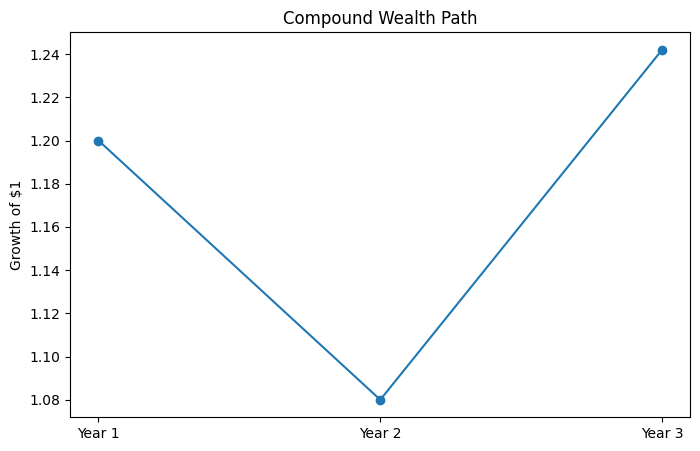

In [12]:
wealth = (1 + returns).cumprod()
wealth.index = ["Year 1", "Year 2", "Year 3"]
plt.figure(figsize=(8, 5))
plt.plot(wealth.index, wealth.values, marker="o")
plt.ylabel("Growth of $1")
plt.title("Compound Wealth Path")
plt.show()

## 25. Geometric Growth, Time Weighting, and Fund Size

The geometric average return is time-weighted because each period receives equal weight in the compound growth calculation:

$$
1 + \bar{R}_G = \left[\prod_{t=1}^{T}(1+R_t)\right]^{1/T}
$$

This makes it useful for evaluating the performance of an investment strategy independent of external cash flows.

But investors often add or withdraw capital through time. A fund manager may produce high returns when the fund is small and lower returns when the fund is large. The time-weighted return may look excellent even if most investor dollars arrived later and earned weaker returns.

This creates a distinction between:

1. **Time-weighted returns**: performance of one dollar invested at the start and left in the fund.
2. **Money-weighted returns**: performance accounting for the timing and size of external cash flows.

The internal rate of return is a money-weighted return. It solves:

$$
0 = \sum_{t=0}^{T} \frac{CF_t}{(1+IRR)^t}
$$

A manager may have an excellent early record, attract large inflows, and then deliver mediocre results on much larger assets under management. In that case, the time-weighted return may overstate the experience of the average investor dollar.

In [13]:
# Same manager returns, but capital arrives after the best early years.
fund = pd.DataFrame({
    "Year": [1, 2, 3, 4, 5],
    "Return": [0.40, 0.30, 0.05, 0.03, 0.02],
    "Beginning AUM": [10, 15, 200, 240, 260]
})
fund["Dollar Gain"] = fund["Beginning AUM"] * fund["Return"]

time_weighted_geo = np.prod(1 + fund["Return"]) ** (1 / len(fund)) - 1
aum_weighted_return = fund["Dollar Gain"].sum() / fund["Beginning AUM"].sum()

fund, pd.Series({
    "Time-Weighted Geometric Average": time_weighted_geo,
    "AUM-Weighted Average Return": aum_weighted_return
}).to_frame("Performance Measure")

(   Year  Return  Beginning AUM  Dollar Gain
 0     1  0.4000             10       4.0000
 1     2  0.3000             15       4.5000
 2     3  0.0500            200      10.0000
 3     4  0.0300            240       7.2000
 4     5  0.0200            260       5.2000,
                                  Performance Measure
 Time-Weighted Geometric Average               0.1496
 AUM-Weighted Average Return                   0.0426)

## 26. Volatility Drag: Geometric Average, Arithmetic Average, and Variance

For continuously compounded returns, the connection between arithmetic and geometric returns is exact by construction because log returns add through time. For simple returns, a common approximation links the arithmetic mean and the geometric mean.

When returns are approximately normally distributed and not too large, the geometric average is approximately:

$$
\bar{R}_G \approx \bar{R}_A - \frac{1}{2}\sigma^2
$$

This is sometimes called the volatility drag formula. It says that higher variance lowers compound growth, even if the arithmetic mean is unchanged.

The intuition is simple. A loss hurts compound wealth more than an equal-sized gain helps it. The concavity of the logarithm creates the penalty:

$$
\mathbb{E}[\ln(1+R)] < \ln(1+\mathbb{E}[R])
$$

unless returns are nonrandom.

In [14]:
# Demonstrate volatility drag with simulated annual returns.
annual_mean = 0.08
vol_levels = np.array([0.05, 0.10, 0.20, 0.30, 0.40])
rows = []

for vol in vol_levels:
    simulated = np.random.normal(annual_mean, vol, 250_000)
    simulated = simulated[simulated > -0.99]  # keep simple returns economically meaningful
    arithmetic = simulated.mean()
    geometric = np.exp(np.log1p(simulated).mean()) - 1
    approximation = arithmetic - 0.5 * simulated.var(ddof=0)
    rows.append([vol, arithmetic, geometric, approximation])

vol_drag = pd.DataFrame(rows, columns=["Volatility", "Arithmetic Mean", "Geometric Mean", "Arithmetic - Half Variance"])
vol_drag

,Volatility,Arithmetic Mean,Geometric Mean,Arithmetic - Half Variance
0,0.0500,0.0800,0.0789,0.0788
1,0.1000,0.0797,0.0751,0.0747
2,0.2000,0.0800,0.0606,0.0600
3,0.3000,0.0789,0.0316,0.0341
4,0.4000,0.0845,-0.0053,0.0065


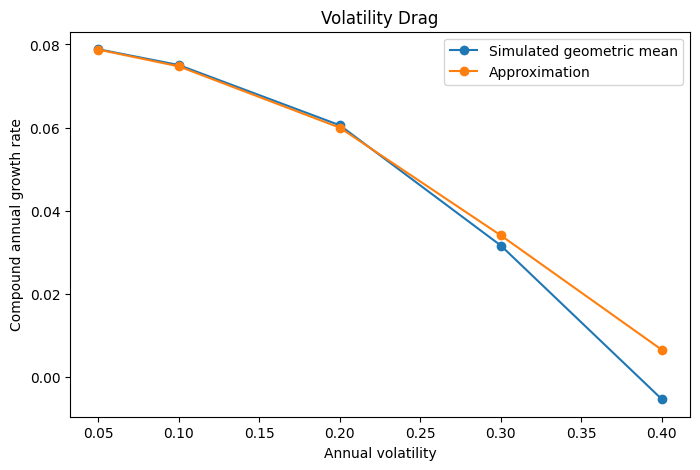

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(vol_drag["Volatility"], vol_drag["Geometric Mean"], marker="o", label="Simulated geometric mean")
plt.plot(vol_drag["Volatility"], vol_drag["Arithmetic - Half Variance"], marker="o", label="Approximation")
plt.xlabel("Annual volatility")
plt.ylabel("Compound annual growth rate")
plt.title("Volatility Drag")
plt.legend()
plt.show()

## 27. Recovering From Losses

A negative return requires a larger positive return to recover the original portfolio value.

If a portfolio loses \(L\), its value falls from \(1\) to \(1-L\). The required gain \(G\) to return to \(1\) satisfies:

$$
(1-L)(1+G)=1
$$

Therefore:

$$
G = \frac{L}{1-L}
$$

A 10% loss requires an 11.11% gain. A 50% loss requires a 100% gain. A 90% loss requires a 900% gain.

This is one reason downside risk matters so much for long-horizon investors.

In [16]:
losses = np.array([0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 0.90])
recovery = losses / (1 - losses)
recovery_table = pd.DataFrame({
    "Loss": losses,
    "Required Gain to Break Even": recovery
})
recovery_table

,Loss,Required Gain to Break Even
0,0.0500,0.0526
1,0.1000,0.1111
2,0.2000,0.2500
3,0.3000,0.4286
4,0.5000,1.0000
5,0.7500,3.0000
6,0.9000,9.0000


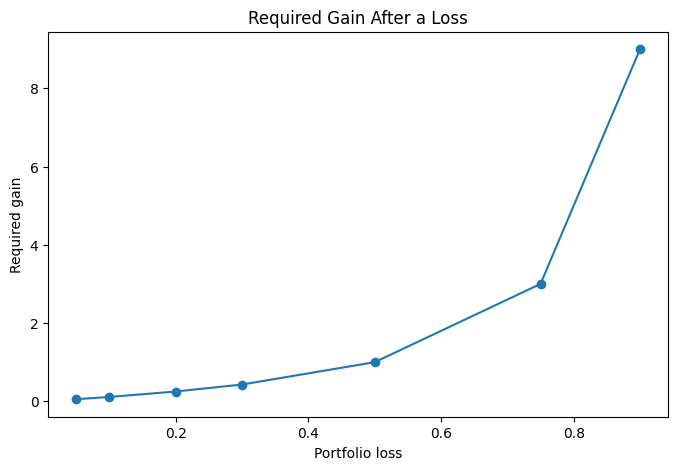

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(recovery_table["Loss"], recovery_table["Required Gain to Break Even"], marker="o")
plt.xlabel("Portfolio loss")
plt.ylabel("Required gain")
plt.title("Required Gain After a Loss")
plt.show()

## 28. Annualizing Average Returns and Standard Deviations

Annualization depends on whether the returns are simple returns or log returns.

For simple periodic returns, if \(\bar{R}_{m}\) is a monthly arithmetic average, a rough annualized arithmetic return is:

$$
\bar{R}_{annual} \approx 12\bar{R}_{m}
$$

A compounded annualized return is:

$$
R_{annual} = (1+\bar{R}_{m})^{12}-1
$$

For a realized time series of monthly returns, the annualized geometric mean is:

$$
\bar{R}_{G,annual}
= \left[\prod_{t=1}^{T}(1+R_t)\right]^{12/T}-1
$$

For log returns, annualization is especially simple. If monthly log returns are \(r_t = \ln(1+R_t)\), then:

$$
\bar{r}_{annual} = 12\bar{r}_{monthly}
$$

and the corresponding annual simple return is:

$$
R_{annual} = e^{\bar{r}_{annual}}-1
$$

Standard deviations are annualized using the square-root-of-time rule when returns are independent and identically distributed:

$$
\sigma_{annual} = \sigma_{periodic}\sqrt{k}
$$

where \(k\) is the number of periods per year. For monthly returns, \(k=12\). For daily returns, analysts often use \(k=252\) trading days.

The square-root rule can fail when returns are serially correlated, volatility changes through time, or the return distribution has regime shifts.

In [18]:
# Annualization demonstration using synthetic monthly returns.
monthly = pd.Series(np.random.normal(0.007, 0.04, 120), name="Monthly Return")

monthly_arithmetic = monthly.mean()
annual_arithmetic_simple = 12 * monthly_arithmetic
annual_compounded_from_avg = (1 + monthly_arithmetic) ** 12 - 1
annual_geometric_realized = np.prod(1 + monthly) ** (12 / len(monthly)) - 1
monthly_log = np.log1p(monthly)
annual_log_mean = 12 * monthly_log.mean()
annual_simple_from_log = np.exp(annual_log_mean) - 1
annualized_vol = monthly.std(ddof=1) * math.sqrt(12)

pd.DataFrame({
    "Monthly Arithmetic Mean": [monthly_arithmetic],
    "Annualized Arithmetic Approximation": [annual_arithmetic_simple],
    "Annualized Compounded from Monthly Average": [annual_compounded_from_avg],
    "Realized Annualized Geometric Mean": [annual_geometric_realized],
    "Annual Simple Return from Mean Log Return": [annual_simple_from_log],
    "Annualized Standard Deviation": [annualized_vol]
})

,Monthly Arithmetic Mean,Annualized Arithmetic Approximation,Annualized Compounded from Monthly Average,Realized Annualized Geometric Mean,Annual Simple Return from Mean Log Return,Annualized Standard Deviation
0,0.0064,0.0772,0.0800,0.0683,0.0683,0.1495


# Part IV. Return Statistics: What the Distribution Looks Like

Once we have a return series, we summarize it with probability concepts. The order matters: expected return comes first, then dispersion, then asymmetry and tail thickness. These are statistical descriptions of the return distribution, not yet complete measures of economic risk.


## 29. Expected Returns

An expected return is a probability-weighted average of possible returns.

Suppose there are $ N $ possible states of the world. State $ s $ occurs with probability $ p_s $, and the asset return in that state is $ R_s $.

The expected return is:

$$
\mathbb{E}[R] = \sum_{s=1}^N p_s R_s
$$

Example:

| State | Probability | Return |
|---|---:|---:|
| Boom | 0.25 | 20% |
| Normal | 0.50 | 8% |
| Recession | 0.25 | -10% |

Then:

$$
\mathbb{E}[R]
=
0.25(0.20)
+
0.50(0.08)
+
0.25(-0.10)
$$

$$
\mathbb{E}[R]
=
0.05 + 0.04 - 0.025
$$

$$
\mathbb{E}[R] = 0.065 = 6.5\%
$$

The expected return is not necessarily the return that will occur. It is the probability-weighted mean of the distribution.

---

### Python Demonstration: Expected Return, Variance, and Standard Deviation

This cell implements the state-contingent return distribution from the notes. It is a probability model, not a historical time series.

In [19]:
states = pd.DataFrame({
    "State": ["Boom", "Normal", "Recession"],
    "Probability": [0.25, 0.50, 0.25],
    "Return": [0.20, 0.08, -0.10]
})

expected_return = (states["Probability"] * states["Return"]).sum()
states["Deviation"] = states["Return"] - expected_return
states["Weighted Squared Deviation"] = states["Probability"] * states["Deviation"] ** 2
variance = states["Weighted Squared Deviation"].sum()
std_dev = math.sqrt(variance)

states, pd.DataFrame({"Expected Return": [expected_return], "Variance": [variance], "Standard Deviation": [std_dev]})

(       State  Probability  Return  Deviation  Weighted Squared Deviation
 0       Boom       0.2500  0.2000     0.1350                      0.0046
 1     Normal       0.5000  0.0800     0.0150                      0.0001
 2  Recession       0.2500 -0.1000    -0.1650                      0.0068,
    Expected Return  Variance  Standard Deviation
 0           0.0650    0.0115              0.1071)

### Python Demonstration: Historical Frequencies as Empirical Probabilities

A historical return series can be converted into a crude empirical probability distribution. This is frequentist in spirit: the probability of an event is estimated by its relative frequency in the observed sample.

In [20]:
# Turn the simulated return history into frequency bins.
bins = [-np.inf, -0.10, -0.05, 0.00, 0.05, 0.10, np.inf]
labels = ["Below -10%", "-10% to -5%", "-5% to 0%", "0% to 5%", "5% to 10%", "Above 10%"]
frequency_table = pd.cut(simulated_returns, bins=bins, labels=labels).value_counts().sort_index().to_frame("Count")
frequency_table["Relative frequency"] = frequency_table["Count"] / frequency_table["Count"].sum()
frequency_table


,Count,Relative frequency
Simulated Monthly Return,,
Below -10%,15,0.0625
-10% to -5%,12,0.0500
-5% to 0%,77,0.3208
0% to 5%,103,0.4292
5% to 10%,31,0.1292
Above 10%,2,0.0083


In [21]:
# Expected return estimated from empirical frequencies is the same as the sample mean
# when every historical observation receives equal weight.
empirical_expected_return = simulated_returns.mean()
manual_expected_return = sum(simulated_returns.value_counts(normalize=True).index * simulated_returns.value_counts(normalize=True).values)

pd.DataFrame({
    "Method": ["pandas mean", "manual probability-weighted mean"],
    "Estimated expected monthly return": [empirical_expected_return, manual_expected_return]
})


,Method,Estimated expected monthly return
0,pandas mean,-0.0019
1,manual probability-weighted mean,-0.0019


## 30. Variance and Standard Deviation

Variance measures the average squared deviation of returns from their expected value.

For a probability distribution:

$$
\sigma^2 = \operatorname{Var}(R)
=
\sum_{s=1}^N p_s (R_s - \mathbb{E}[R])^2
$$

Standard deviation is the square root of variance:

$$
\sigma = \sqrt{\operatorname{Var}(R)}
$$

Using the previous example:

$$
\mathbb{E}[R] = 6.5\%
$$

The deviations are:

- Boom: $ 20\% - 6.5\% = 13.5\% $
- Normal: $ 8\% - 6.5\% = 1.5\% $
- Recession: $ -10\% - 6.5\% = -16.5\% $

The variance is:

$$
\sigma^2
=
0.25(0.135)^2
+
0.50(0.015)^2
+
0.25(-0.165)^2
$$

$$
\sigma^2
=
0.25(0.018225)
+
0.50(0.000225)
+
0.25(0.027225)
$$

$$
\sigma^2
=
0.00455625 + 0.0001125 + 0.00680625
$$

$$
\sigma^2 = 0.011475
$$

The standard deviation is:

$$
\sigma = \sqrt{0.011475}
$$

$$
\sigma \approx 0.1071 = 10.71\%
$$

Standard deviation is useful because it is measured in the same units as returns.

Variance is mathematically convenient, but standard deviation is easier to interpret.

---

### Python Demonstration: Mean, Variance, Standard Deviation, Skewness, and Kurtosis

The following cell introduces the main Python functions students need for basic return statistics. Pandas uses sample versions of these statistics by default. In particular, `var()` and `std()` use `ddof=1`, meaning the denominator is $T-1$ rather than $T$.

In [22]:
# Basic descriptive statistics using pandas.
descriptive_stats = pd.DataFrame({
    "Statistic": [
        "Arithmetic mean",
        "Variance, sample ddof=1",
        "Variance, population ddof=0",
        "Standard deviation, sample ddof=1",
        "Standard deviation, population ddof=0",
        "Skewness",
        "Excess kurtosis",
        "Minimum",
        "Maximum"
    ],
    "Value": [
        simulated_returns.mean(),
        simulated_returns.var(ddof=1),
        simulated_returns.var(ddof=0),
        simulated_returns.std(ddof=1),
        simulated_returns.std(ddof=0),
        simulated_returns.skew(),
        simulated_returns.kurt(),
        simulated_returns.min(),
        simulated_returns.max()
    ]
})

descriptive_stats["Value"] = descriptive_stats["Value"].map(lambda x: f"{x:.4f}")
descriptive_stats


,Statistic,Value
0,Arithmetic mean,-0.0019
1,"Variance, sample ddof=1",0.0036
2,"Variance, population ddof=0",0.0035
3,"Standard deviation, sample ddof=1",0.0596
4,"Standard deviation, population ddof=0",0.0595
5,Skewness,-1.7646
6,Excess kurtosis,4.7511
7,Minimum,-0.2717
8,Maximum,0.1183


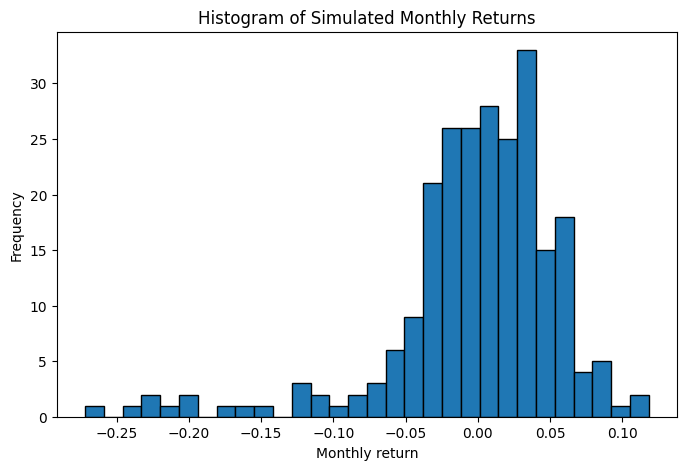

In [23]:
# Histogram of simulated returns.
plt.figure(figsize=(8, 5))
plt.hist(simulated_returns, bins=30, edgecolor="black")
plt.xlabel("Monthly return")
plt.ylabel("Frequency")
plt.title("Histogram of Simulated Monthly Returns")
plt.show()


## 31. Skewness

Variance treats upside and downside deviations symmetrically. But investors often care about asymmetry.

**Skewness** measures the asymmetry of a distribution.

A return distribution has **positive skewness** if it has a long right tail. That means a small chance of very large positive returns.

Examples:

- Venture capital
- Call options
- Lottery-like stocks
- Early-stage biotechnology firms

A return distribution has **negative skewness** if it has a long left tail. That means a small chance of very large losses.

Examples:

- Selling insurance
- Selling put options
- Leveraged carry trades
- Highly levered financial institutions

The population skewness is:

$$
\text{Skewness}
=
\mathbb{E}
\left[
\left(
\frac{R - \mu}{\sigma}
\right)^3
\right]
$$

where:

- $ \mu = \mathbb{E}[R] $,
- $ \sigma $ is the standard deviation.

Positive skewness is often attractive because investors like upside potential.

Negative skewness is dangerous because ordinary periods may look stable while rare crashes impose severe losses.

A strategy that earns small steady gains and occasionally crashes may have high average returns for a while, but its negative skewness can be economically important.

---

## 32. Kurtosis

**Kurtosis** measures the thickness of the tails of a distribution relative to the normal distribution.

The population kurtosis is:

$$
\text{Kurtosis}
=
\mathbb{E}
\left[
\left(
\frac{R - \mu}{\sigma}
\right)^4
\right]
$$

A normal distribution has kurtosis equal to 3.

Excess kurtosis is:

$$
\text{Excess kurtosis} = \text{Kurtosis} - 3
$$

High excess kurtosis means the distribution has fat tails. Extreme observations occur more often than they would under a normal distribution.

In investment analysis, kurtosis matters because many financial return distributions have fat tails. Crashes and extreme rallies occur more frequently than a simple normal model predicts.

Variance and standard deviation summarize ordinary dispersion. Skewness and kurtosis help describe tail risk.

---

# Part V. Estimation, Sampling, and Rolling Windows

Historical returns are samples, not immutable laws of nature. This section explains how estimation error, degrees of freedom, sample duration, stationarity, and rolling windows affect the interpretation of return statistics.


## 33. Degrees-of-Freedom Bias and the Sample Variance

If we observe the entire population of returns, the population variance is:

$$
\sigma^2 = \frac{1}{N}\sum_{i=1}^{N}(R_i-\mu)^2
$$

But in practice we usually observe a sample and do not know the true population mean \(\mu\). We estimate it using the sample mean \(\bar{R}\). Because the same data are used to estimate the mean and the squared deviations around the mean, the naive variance estimator is biased downward:

$$
\frac{1}{T}\sum_{t=1}^{T}(R_t-\bar{R})^2
$$

The unbiased sample variance uses \(T-1\) in the denominator:

$$
s^2 = \frac{1}{T-1}\sum_{t=1}^{T}(R_t-\bar{R})^2
$$

The phrase **degrees of freedom** means that once \(T-1\) deviations from the sample mean are known, the final deviation is pinned down because deviations from the sample mean sum to zero.

For large samples, the difference between \(T\) and \(T-1\) is small. For small samples, it can matter.

In [24]:
# Monte Carlo demonstration of the downward bias from dividing by T instead of T-1.
true_variance = 0.04
true_std = math.sqrt(true_variance)
sample_size = 6
num_samples = 100_000
samples = np.random.normal(0, true_std, size=(num_samples, sample_size))

biased_variance = samples.var(axis=1, ddof=0)
unbiased_variance = samples.var(axis=1, ddof=1)

pd.DataFrame({
    "True Variance": [true_variance],
    "Average Biased Estimate, divide by T": [biased_variance.mean()],
    "Average Unbiased Estimate, divide by T-1": [unbiased_variance.mean()]
})

,True Variance,"Average Biased Estimate, divide by T","Average Unbiased Estimate, divide by T-1"
0,0.0400,0.0334,0.0401


## 34. Frequency, Sample Duration, and the Accuracy of Return Estimates

It is tempting to think that using daily data instead of monthly data automatically solves the problem of estimating expected returns. It usually does not.

For estimating average returns, **sample duration matters more than sampling frequency**.

Suppose returns are independent with per-period standard deviation \(\sigma\). The standard error of the sample mean is:

$$
SE(\bar{R}) = \frac{\sigma}{\sqrt{T}}
$$

Daily data increase \(T\), but daily expected returns are also much smaller than annual expected returns, and daily returns are noisy. If the goal is to estimate the annual expected return, collecting more observations within the same calendar span helps less than extending the sample across more years.

For volatility estimation, higher frequency can help because volatility is more precisely estimated than expected return. But for mean returns, the signal-to-noise problem is severe.

The key practical point is:

> More frequent observations over the same calendar period do not create the same information as observing more independent years of economic history.

Serial correlation, bid-ask bounce, nonsynchronous trading, illiquidity, time-varying volatility, and regime changes complicate the problem further.

In [25]:
# Standard error of the annualized mean for different sample durations.
annual_vol = 0.18
years = np.array([1, 3, 5, 10, 20, 50])
standard_error_annual_mean = annual_vol / np.sqrt(years)

se_table = pd.DataFrame({
    "Sample Duration in Years": years,
    "Std. Error of Annual Mean Return": standard_error_annual_mean
})
se_table

,Sample Duration in Years,Std. Error of Annual Mean Return
0,1,0.1800
1,3,0.1039
2,5,0.0805
3,10,0.0569
4,20,0.0402
5,50,0.0255


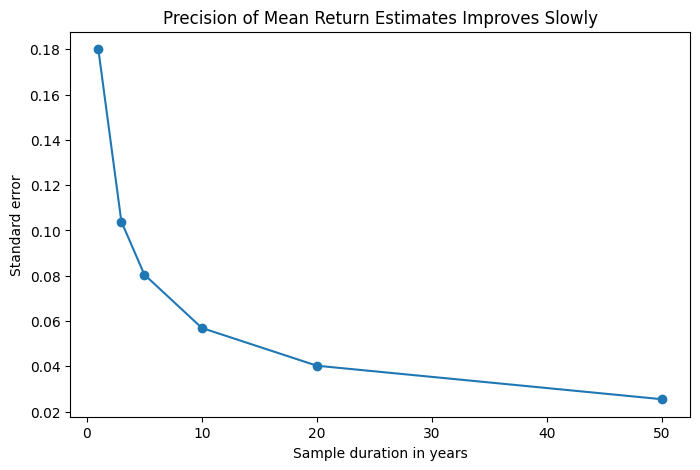

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(se_table["Sample Duration in Years"], se_table["Std. Error of Annual Mean Return"], marker="o")
plt.xlabel("Sample duration in years")
plt.ylabel("Standard error")
plt.title("Precision of Mean Return Estimates Improves Slowly")
plt.show()

## 35. Stationarity

A time series is stationary when its probability distribution is stable through time. A weakly stationary return process has:

1. constant mean,
2. constant variance,
3. autocovariances that depend only on the lag, not on calendar time.

Stationarity matters because historical estimates are useful only if the past and future are governed by a sufficiently stable data-generating process.

If expected returns, volatility, correlations, inflation, monetary policy, leverage, market structure, or investor composition change through time, then old data may be a poor guide to the future.

Financial returns are often closer to stationary than prices, but even returns can exhibit changing volatility, changing risk premia, crashes, bubbles, regime changes, and structural breaks.

This does not mean historical analysis is useless. It means that historical statistics should be interpreted as estimates from a particular sample, not as timeless constants.

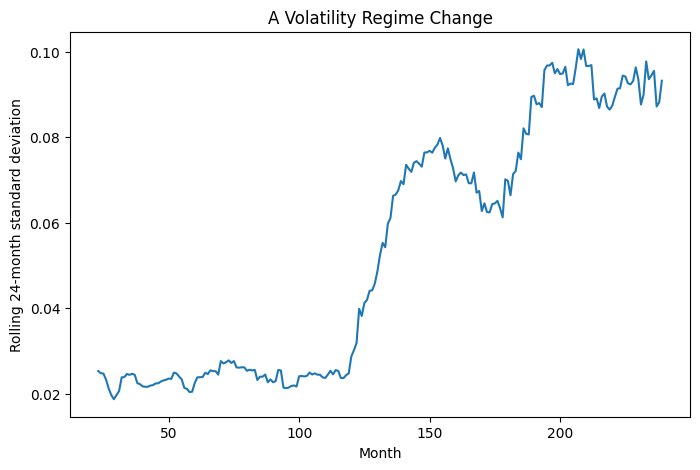

In [27]:
# A stylized nonstationary return process with a volatility regime change.
low_vol = np.random.normal(0.006, 0.025, 120)
high_vol = np.random.normal(0.006, 0.080, 120)
regime_returns = pd.Series(np.r_[low_vol, high_vol], name="Monthly Return")
rolling_vol = regime_returns.rolling(24).std()

plt.figure(figsize=(8, 5))
plt.plot(rolling_vol.index, rolling_vol.values)
plt.xlabel("Month")
plt.ylabel("Rolling 24-month standard deviation")
plt.title("A Volatility Regime Change")
plt.show()

## 36. Tricks of the Trade: Moving Averages and Moving Standard Deviations

Rolling statistics are often used to examine whether the return process appears stable over time. A moving average estimates local performance. A moving standard deviation estimates local volatility. These are useful exploratory tools, but they should not be confused with structural laws.

In [28]:
# Calculate 12-month and 36-month moving averages and moving standard deviations.
rolling_table = pd.DataFrame({
    "Return": simulated_returns,
    "12-month moving average": simulated_returns.rolling(12).mean(),
    "36-month moving average": simulated_returns.rolling(36).mean(),
    "12-month moving standard deviation": simulated_returns.rolling(12).std(),
    "36-month moving standard deviation": simulated_returns.rolling(36).std()
})

rolling_table.tail(10)


,Return,12-month moving average,36-month moving average,12-month moving standard deviation,36-month moving standard deviation
2025-03-01,0.0005,-0.0437,-0.0203,0.0809,0.0634
2025-04-01,0.0648,-0.0358,-0.0173,0.0868,0.0648
2025-05-01,0.0617,-0.0268,-0.0144,0.0911,0.0660
2025-06-01,0.0597,-0.0207,-0.0133,0.0945,0.0669
2025-07-01,0.0808,-0.0130,-0.0113,0.0989,0.0686
2025-08-01,-0.0346,0.0068,-0.0127,0.0576,0.0686
2025-09-01,0.0316,0.0076,-0.0122,0.0579,0.0688
2025-10-01,0.0346,0.0104,-0.0118,0.0584,0.0690
2025-11-01,-0.2154,0.0030,-0.0153,0.0792,0.0759
2025-12-01,0.0824,0.0113,-0.0134,0.0821,0.0775


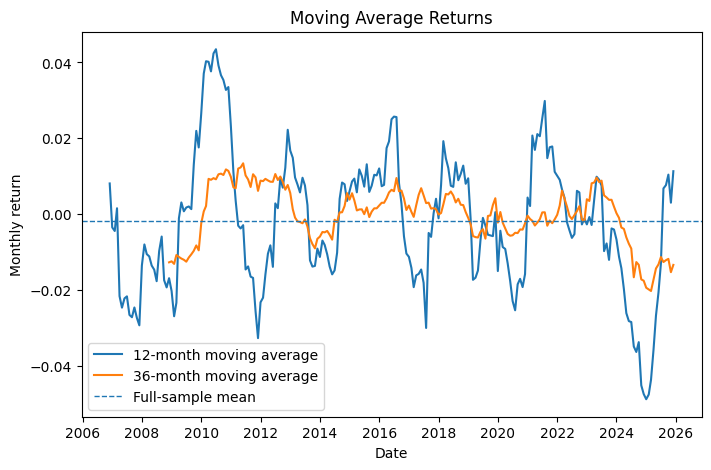

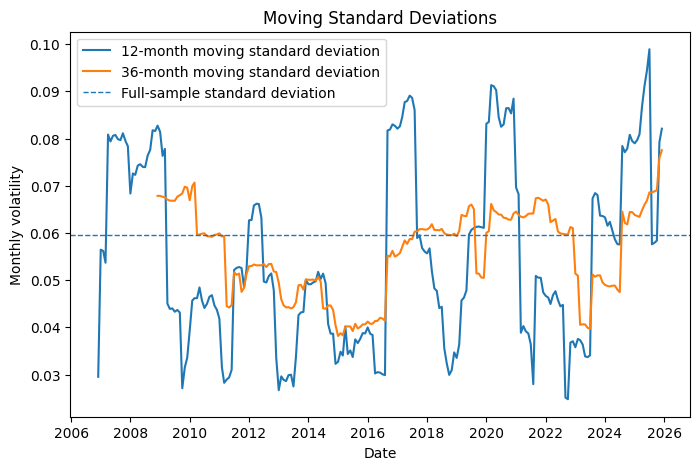

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(rolling_table.index, rolling_table["12-month moving average"], label="12-month moving average")
plt.plot(rolling_table.index, rolling_table["36-month moving average"], label="36-month moving average")
plt.axhline(simulated_returns.mean(), linestyle="--", linewidth=1, label="Full-sample mean")
plt.xlabel("Date")
plt.ylabel("Monthly return")
plt.title("Moving Average Returns")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(rolling_table.index, rolling_table["12-month moving standard deviation"], label="12-month moving standard deviation")
plt.plot(rolling_table.index, rolling_table["36-month moving standard deviation"], label="36-month moving standard deviation")
plt.axhline(simulated_returns.std(), linestyle="--", linewidth=1, label="Full-sample standard deviation")
plt.xlabel("Date")
plt.ylabel("Monthly volatility")
plt.title("Moving Standard Deviations")
plt.legend()
plt.show()


## 37. Rolling Skewness, Rolling Kurtosis, and Three-Sigma Tail Events

A strategy can look acceptable by mean and standard deviation while still having changing tail risk. Rolling skewness and rolling kurtosis are noisy, but they help students see that higher moments are sample estimates, not fixed facts handed down by nature.

In [30]:
rolling_tail_risk = pd.DataFrame({
    "36-month rolling skewness": simulated_returns.rolling(36).skew(),
    "36-month rolling excess kurtosis": simulated_returns.rolling(36).kurt()
})

rolling_tail_risk.tail(10)


,36-month rolling skewness,36-month rolling excess kurtosis
2025-03-01,-2.5493,7.4797
2025-04-01,-2.4641,7.1699
2025-05-01,-2.4240,6.9948
2025-06-01,-2.3416,6.6668
2025-07-01,-2.1836,6.1002
2025-08-01,-2.1272,5.9263
2025-09-01,-2.1197,5.8614
2025-10-01,-2.1109,5.8046
2025-11-01,-1.9904,4.2165
2025-12-01,-1.8890,3.9069


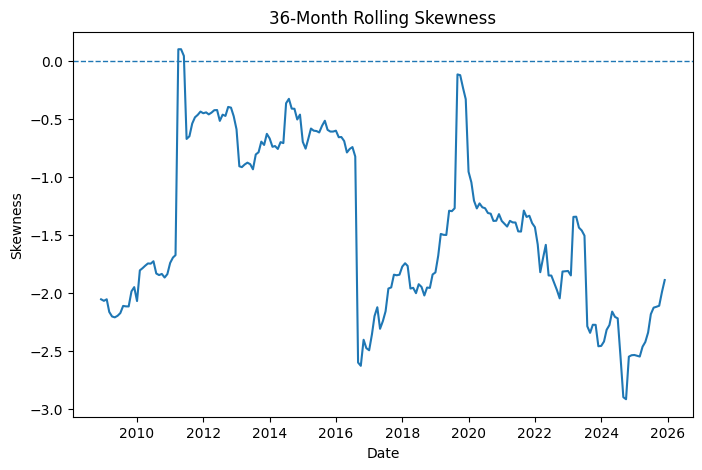

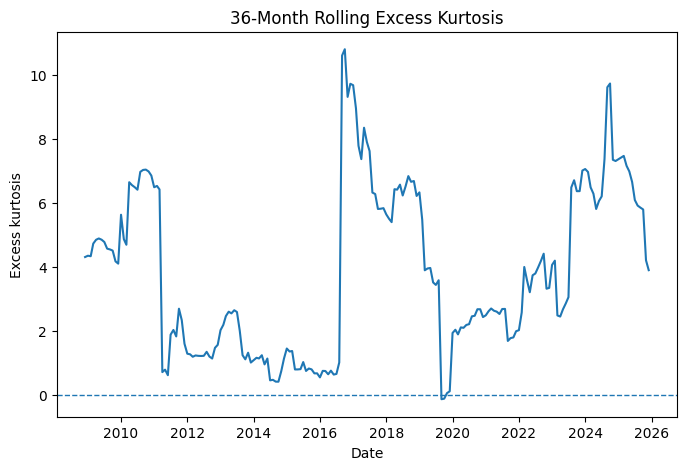

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(rolling_tail_risk.index, rolling_tail_risk["36-month rolling skewness"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Date")
plt.ylabel("Skewness")
plt.title("36-Month Rolling Skewness")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(rolling_tail_risk.index, rolling_tail_risk["36-month rolling excess kurtosis"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Date")
plt.ylabel("Excess kurtosis")
plt.title("36-Month Rolling Excess Kurtosis")
plt.show()


In [32]:
# Relative frequency of large negative returns using the full-sample mean and standard deviation.
mu_hat = simulated_returns.mean()
sigma_hat = simulated_returns.std(ddof=1)
three_sigma_cutoff = mu_hat - 3 * sigma_hat
large_negative_events = simulated_returns < three_sigma_cutoff

three_sigma_table = pd.DataFrame({
    "Sample mean": [mu_hat],
    "Sample standard deviation": [sigma_hat],
    "Mean minus 3 standard deviations": [three_sigma_cutoff],
    "Number of returns below cutoff": [large_negative_events.sum()],
    "Relative frequency below cutoff": [large_negative_events.mean()]
})
three_sigma_table


,Sample mean,Sample standard deviation,Mean minus 3 standard deviations,Number of returns below cutoff,Relative frequency below cutoff
0,-0.0019,0.0596,-0.1807,7,0.0292


## 38. Hurst Exponents and Fractal Self-Similarity


# 40. Hurst Exponents and Fractal Self-Similarity

Many return models assume that returns are independent draws from a stable distribution. That assumption is useful, but financial markets often display clustering, persistence, regime shifts, and scale-dependent behavior. The **Hurst exponent** is one tool for describing whether a time series behaves like a memoryless random walk, a persistent process, or an anti-persistent mean-reverting process.

The Hurst exponent is usually denoted by $H$.

A rough interpretation is:

| Hurst exponent | Interpretation |
|---:|---|
| $H \approx 0.5$ | Random-walk-like behavior; no long-memory persistence. |
| $H > 0.5$ | Persistence; increases tend to be followed by increases, and decreases by decreases. |
| $H < 0.5$ | Anti-persistence; increases tend to be followed by reversals. |

The key scaling idea is that the typical magnitude of changes over a horizon $k$ scales approximately as:

$$
\operatorname{Std}(X_{t+k}-X_t) \propto k^H.
$$

Taking logs gives a regression-style relationship:

$$
\log \operatorname{Std}(X_{t+k}-X_t) = a + H \log(k) + \varepsilon_k.
$$

The slope of the log-log relationship is an estimate of $H$.

This is connected to **fractal self-similarity**. A process is self-similar if its statistical appearance is related across different time scales. In finance, this does not mean that daily, monthly, and annual returns are literally identical. It means that some statistical patterns may scale in systematic ways across horizons.

The practical lesson is cautious:

> Hurst exponents are exploratory diagnostics, not magic forecasting tools.

A high estimated $H$ may reflect genuine persistence, but it may also reflect structural breaks, nonstationarity, volatility regimes, or sample-specific trends. Before interpreting $H$ as evidence of exploitable predictability, the analyst should ask whether the underlying process is stable enough for the estimate to mean what it appears to mean.


In [33]:

# Hurst exponent demonstration using log-log scaling of increments.
# We create three synthetic level series:
# 1. A random walk-like process.
# 2. A process with persistent increments.
# 3. A process with anti-persistent increments.

rng = np.random.default_rng(2029)
n = 1_500

random_walk_increments = rng.normal(0, 1, n)
random_walk_level = np.cumsum(random_walk_increments)

persistent_increments = np.empty(n)
persistent_increments[0] = rng.normal()
for t in range(1, n):
    persistent_increments[t] = 0.70 * persistent_increments[t-1] + rng.normal(0, 1)
persistent_level = np.cumsum(persistent_increments)

antipersistent_increments = np.empty(n)
antipersistent_increments[0] = rng.normal()
for t in range(1, n):
    antipersistent_increments[t] = -0.70 * antipersistent_increments[t-1] + rng.normal(0, 1)
antipersistent_level = np.cumsum(antipersistent_increments)

hurst_series = pd.DataFrame({
    "Random walk-like level": random_walk_level,
    "Persistent-increment level": persistent_level,
    "Anti-persistent-increment level": antipersistent_level,
})

hurst_series.head()


,Random walk-like level,Persistent-increment level,Anti-persistent-increment level
0,-0.2541,1.1181,1.2842
1,0.3831,2.5658,-1.3291
2,-0.3607,4.1763,-0.2003
3,1.0952,6.7053,-1.3694
4,1.1261,9.1824,1.3281


In [34]:

def estimate_hurst_loglog(series, min_lag=2, max_lag=100):
    # Estimate the Hurst exponent from the scaling of lagged differences.
    x = np.asarray(series, dtype=float)
    lags = np.arange(min_lag, max_lag + 1)
    tau = []
    valid_lags = []
    for lag in lags:
        diffs = x[lag:] - x[:-lag]
        sd = np.std(diffs, ddof=1)
        if sd > 0:
            tau.append(sd)
            valid_lags.append(lag)
    valid_lags = np.asarray(valid_lags)
    tau = np.asarray(tau)
    slope, intercept = np.polyfit(np.log(valid_lags), np.log(tau), 1)
    return slope, intercept, valid_lags, tau

hurst_results = []
scaling_data = {}

for col in hurst_series.columns:
    H, intercept, lags, tau = estimate_hurst_loglog(hurst_series[col], min_lag=2, max_lag=100)
    hurst_results.append({"Series": col, "Estimated Hurst exponent": H})
    scaling_data[col] = (H, intercept, lags, tau)

pd.DataFrame(hurst_results)


,Series,Estimated Hurst exponent
0,Random walk-like level,0.5571
1,Persistent-increment level,0.5051
2,Anti-persistent-increment level,0.3714


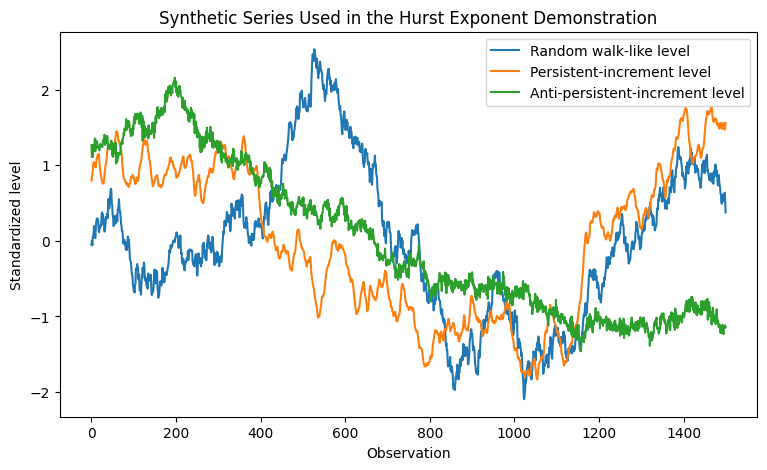

In [35]:

# Plot the synthetic level series.
plt.figure(figsize=(9, 5))
for col in hurst_series.columns:
    standardized = (hurst_series[col] - hurst_series[col].mean()) / hurst_series[col].std()
    plt.plot(standardized.index, standardized.values, label=col)
plt.xlabel("Observation")
plt.ylabel("Standardized level")
plt.title("Synthetic Series Used in the Hurst Exponent Demonstration")
plt.legend()
plt.show()


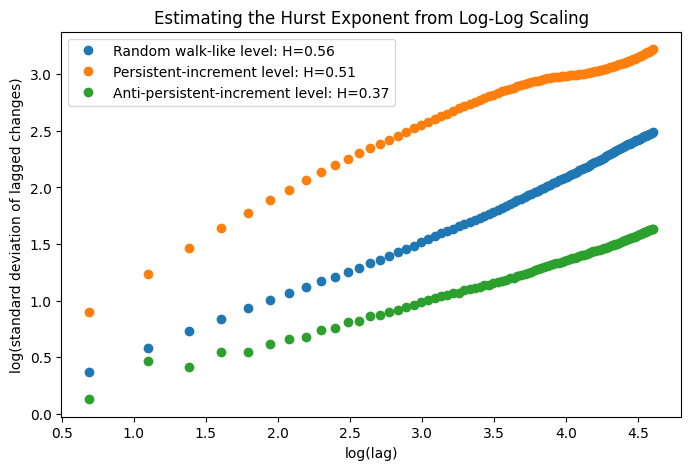

In [36]:

# Plot the log-log scaling relationship.
plt.figure(figsize=(8, 5))
for col, (H, intercept, lags, tau) in scaling_data.items():
    plt.plot(np.log(lags), np.log(tau), marker="o", linestyle="", label=f"{col}: H={H:.2f}")
plt.xlabel("log(lag)")
plt.ylabel("log(standard deviation of lagged changes)")
plt.title("Estimating the Hurst Exponent from Log-Log Scaling")
plt.legend()
plt.show()


### Interpreting Hurst Exponents in Investment Analysis


## Interpreting Hurst Exponents in Investment Analysis

The Hurst exponent is useful because it forces the analyst to think about **time scale**. A return series may look noisy at the daily frequency but smoother over quarterly or annual horizons. Conversely, a series may look stable in a short sample but exhibit regime changes over a longer sample.

Important cautions:

1. **Hurst estimates are sample-dependent.** A short sample can produce a misleading estimate.
2. **Nonstationarity can masquerade as persistence.** A structural break or changing volatility regime can make $H$ appear high.
3. **Trading costs matter.** Even if there is persistence, exploiting it may be costly.
4. **The estimate is descriptive, not structural.** It does not by itself explain why persistence or mean reversion exists.

For portfolio analysis, Hurst exponents belong beside rolling means, rolling volatility, drawdowns, skewness, kurtosis, value at risk, and expected shortfall. They are part of a diagnostic toolkit for asking whether the distribution of returns is stable across time and scale.


# Part VI. Risk Premiums, Downside Risk, and Performance Evaluation

The earlier statistical moments summarize the distribution of returns. Investment analysis also asks whether the investor was compensated for bearing risk. This section introduces risk premiums, Value at Risk, expected shortfall, downside deviation, Sharpe ratios, Sortino ratios, and integrated performance reporting.


## 39. Risk Premiums

A **risk premium** is the expected return on a risky asset in excess of the risk-free rate:

$$
\text{Risk Premium} = \mathbb{E}[R_i] - R_f
$$

In the stochastic-discount-factor framework:

$$
\mathbb{E}[R_i] - R_f = -R_f \operatorname{Cov}(M,R_i)
$$

This equation gives the microfoundation for risk premiums. Assets do not earn higher expected returns simply because their returns are volatile. They earn higher expected returns when they expose investors to bad-state risk.

An asset with returns that are low when the SDF is high has negative covariance with the SDF. That asset is unattractive because it performs badly when marginal utility is high. Investors require a positive risk premium to hold it.

An asset that pays off when the SDF is high provides insurance. Investors may accept a lower expected return because the asset improves consumption precisely when consumption is most valuable.

The risk premium is therefore a price of risk, not a reward for randomness in general.

In [37]:
# A simple comparison of risk premiums from expected returns and the risk-free rate.
expected_returns = pd.Series({
    "Treasury bill": 0.04,
    "Defensive equity": 0.065,
    "Broad equity index": 0.085,
    "Cyclical small-cap equity": 0.115
})
risk_free_rate = 0.04
risk_premiums = (expected_returns - risk_free_rate).rename("Risk Premium")
risk_premiums.to_frame()

,Risk Premium
Treasury bill,0.0000
Defensive equity,0.0250
Broad equity index,0.0450
Cyclical small-cap equity,0.0750


## 40. Other Measures of Risk

Variance and standard deviation are important, but they are not the only useful risk measures. Investment analysts often care especially about downside risk and tail risk.

## 31.1 Value at Risk

For returns, the left-tail Value at Risk at confidence level \(\alpha\) is commonly defined as the positive loss threshold such that losses exceed that amount with probability \(1-\alpha\). If \(q_{1-\alpha}\) is the left-tail return quantile, then:

$$
VaR_{\alpha} = -q_{1-\alpha}(R)
$$

For example, a monthly 95% VaR of 8% means that the portfolio loses more than 8% in the worst 5% of months.

## 31.2 Expected Shortfall

Expected shortfall, also called conditional Value at Risk, measures the average loss conditional on being in the tail:

$$
ES_{\alpha} = -\mathbb{E}[R \mid R \le q_{1-\alpha}(R)]
$$

Expected shortfall is often more informative than VaR because VaR tells us where the tail begins, while expected shortfall tells us how bad the tail is on average.

## 31.3 Lower Partial Standard Deviation

The lower partial standard deviation measures downside dispersion relative to a minimum acceptable return \(MAR\):

$$
\sigma_L = \sqrt{\mathbb{E}\left[\min(R-MAR,0)^2\right]}
$$

Unlike ordinary standard deviation, it does not penalize upside volatility.

## 31.4 Sharpe Ratio

The Sharpe ratio measures excess return per unit of total volatility:

$$
\text{Sharpe Ratio} = \frac{\mathbb{E}[R_p] - R_f}{\sigma_p}
$$

## 31.5 Sortino Ratio

The Sortino ratio replaces total volatility with downside volatility:

$$
\text{Sortino Ratio} = \frac{\mathbb{E}[R_p] - MAR}{\sigma_L}
$$

## 31.6 Relative Frequency of Large Negative Three-Sigma Returns

A useful empirical diagnostic is the relative frequency of returns below three standard deviations under the mean:

$$
\frac{1}{T}\sum_{t=1}^{T} \mathbf{1}\{R_t < \bar{R} - 3s\}
$$

Under a normal distribution, the one-sided probability of observing a return more than three standard deviations below the mean is about 0.13%. In financial data, this frequency is often larger because returns frequently exhibit fat tails, volatility clustering, jumps, leverage, and liquidity spirals.

In [38]:
# Simulate two return distributions with the same approximate mean and volatility:
# one normal and one fat-tailed.
n = 10_000
monthly_mean = 0.006
monthly_vol = 0.045

normal_returns = np.random.normal(monthly_mean, monthly_vol, n)
student_t_raw = np.random.standard_t(df=4, size=n)
student_t_returns = monthly_mean + monthly_vol * student_t_raw / student_t_raw.std(ddof=0)

returns_df = pd.DataFrame({
    "Normal": normal_returns,
    "Fat-tailed": student_t_returns
})

def risk_report(x, rf_monthly=0.002, mar=0.0, alpha=0.95):
    x = pd.Series(x).dropna()
    q = x.quantile(1 - alpha)
    var = -q
    es = -x[x <= q].mean()
    downside = np.minimum(x - mar, 0)
    lpsd = np.sqrt(np.mean(downside ** 2))
    sharpe = (x.mean() - rf_monthly) / x.std(ddof=1)
    sortino = (x.mean() - mar) / lpsd
    three_sigma_threshold = x.mean() - 3 * x.std(ddof=1)
    three_sigma_frequency = (x < three_sigma_threshold).mean()
    return pd.Series({
        "Mean": x.mean(),
        "Std. Dev.": x.std(ddof=1),
        "95% VaR": var,
        "95% Expected Shortfall": es,
        "Lower Partial Std. Dev.": lpsd,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Relative Freq. Below -3 Sigma": three_sigma_frequency
    })

risk_metrics = returns_df.apply(risk_report)
risk_metrics

,Normal,Fat-tailed
Mean,0.0065,0.0058
Std. Dev.,0.0446,0.0450
95% VaR,0.0682,0.0641
95% Expected Shortfall,0.0864,0.0975
Lower Partial Std. Dev.,0.0281,0.0290
Sharpe Ratio,0.1012,0.0835
Sortino Ratio,0.2312,0.1987
Relative Freq. Below -3 Sigma,0.0016,0.0072


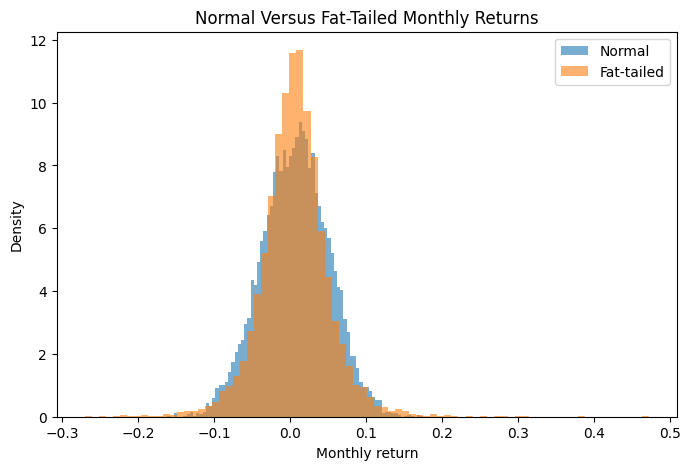

In [39]:
plt.figure(figsize=(8, 5))
plt.hist(returns_df["Normal"], bins=80, alpha=0.6, density=True, label="Normal")
plt.hist(returns_df["Fat-tailed"], bins=80, alpha=0.6, density=True, label="Fat-tailed")
plt.title("Normal Versus Fat-Tailed Monthly Returns")
plt.xlabel("Monthly return")
plt.ylabel("Density")
plt.legend()
plt.show()

### Python Demonstration: Annualization, Rolling Sharpe Ratios, and Rolling Sortino Ratios

Annualization translates periodic statistics into annual units. With monthly returns, a common approximation is:

$$
\mu_{annual} \approx 12\mu_{monthly}
$$

and

$$
\sigma_{annual} \approx \sqrt{12}\sigma_{monthly}
$$

The Sharpe ratio uses total volatility. The Sortino ratio uses downside volatility relative to a target return.

In [40]:
rf_annual_assumption = 0.03
rf_monthly_assumption = (1 + rf_annual_assumption) ** (1 / 12) - 1

def rolling_sharpe(x, rf=rf_monthly_assumption, periods_per_year=12):
    excess = x - rf
    if excess.std(ddof=1) == 0:
        return np.nan
    return np.sqrt(periods_per_year) * excess.mean() / excess.std(ddof=1)

def rolling_sortino(x, target=rf_monthly_assumption, periods_per_year=12):
    downside = np.minimum(x - target, 0)
    downside_deviation = np.sqrt(np.mean(downside ** 2))
    if downside_deviation == 0:
        return np.nan
    return periods_per_year * (x.mean() - target) / (np.sqrt(periods_per_year) * downside_deviation)

rolling_performance = pd.DataFrame({
    "36-month rolling Sharpe ratio": simulated_returns.rolling(36).apply(rolling_sharpe, raw=False),
    "36-month rolling Sortino ratio": simulated_returns.rolling(36).apply(rolling_sortino, raw=False)
})

rolling_performance.tail(10)


,36-month rolling Sharpe ratio,36-month rolling Sortino ratio
2025-03-01,-1.2435,-1.2101
2025-04-01,-1.0549,-1.0569
2025-05-01,-0.8837,-0.9074
2025-06-01,-0.8160,-0.8493
2025-07-01,-0.6972,-0.7443
2025-08-01,-0.7641,-0.8117
2025-09-01,-0.7364,-0.7852
2025-10-01,-0.7171,-0.7670
2025-11-01,-0.8118,-0.8507
2025-12-01,-0.7095,-0.7591


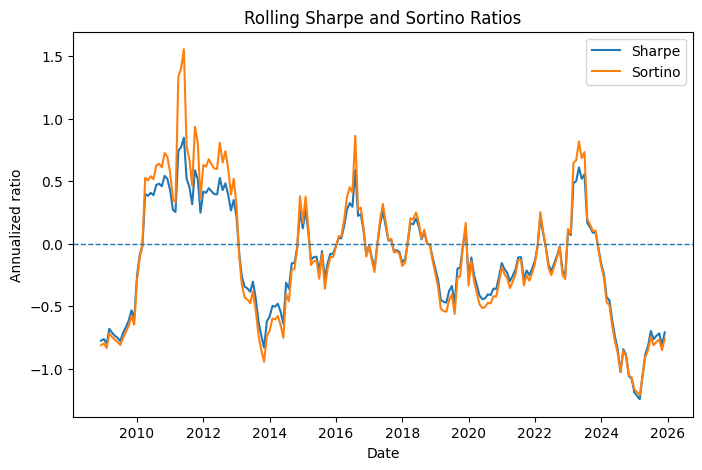

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(rolling_performance.index, rolling_performance["36-month rolling Sharpe ratio"], label="Sharpe")
plt.plot(rolling_performance.index, rolling_performance["36-month rolling Sortino ratio"], label="Sortino")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Date")
plt.ylabel("Annualized ratio")
plt.title("Rolling Sharpe and Sortino Ratios")
plt.legend()
plt.show()


## 41. Bayesian Forward-Looking Scenario Analysis Versus Frequentist Historical Statistics

Historical return analysis usually has a **frequentist** flavor. The analyst observes a time series of realized returns:

$$
R_1, R_2, \ldots, R_T
$$

and estimates quantities such as:

$$
\bar{R} = \frac{1}{T}\sum_{t=1}^{T} R_t
$$

and:

$$
s^2 = \frac{1}{T-1}\sum_{t=1}^{T}(R_t-\bar{R})^2
$$

This approach treats the historical sample as the evidence from which moments are estimated. It is backward-looking. It asks: what did the asset do in the observed data?

Bayesian or forward-looking scenario analysis begins differently. The analyst starts with prior beliefs about possible future states, assigns probabilities to those states, and updates those beliefs as new information arrives.

A scenario table may specify:

$$
\{p_s, R_s\}_{s=1}^{N}
$$

where \(p_s\) is the subjective or model-implied probability of state \(s\), and \(R_s\) is the return if that state occurs.

The expected return is then:

$$
\mathbb{E}[R] = \sum_{s=1}^{N} p_sR_s
$$

This is not necessarily a historical average. It is a forward-looking probability-weighted forecast.

The Bayesian spirit is especially useful when the future is unlikely to resemble the historical sample: regime changes, wars, inflation breaks, policy transitions, new technologies, or major shifts in competition.

The frequentist time-series approach is useful when the data-generating process is stable enough for historical frequencies to be informative. The Bayesian scenario approach is useful when judgment, priors, and structural reasoning are unavoidable.

In [42]:
# Frequentist estimate from historical data versus forward-looking scenario analysis.
historical_monthly_returns = pd.Series(np.random.normal(0.007, 0.04, 120), name="Historical Monthly Return")

frequentist_estimate = pd.Series({
    "Historical Mean Monthly Return": historical_monthly_returns.mean(),
    "Historical Monthly Std. Dev.": historical_monthly_returns.std(ddof=1)
})

scenarios = pd.DataFrame({
    "Scenario": ["Soft landing", "Recession", "Productivity boom", "Inflation shock"],
    "Probability": [0.45, 0.25, 0.20, 0.10],
    "One-Year Return": [0.09, -0.18, 0.24, -0.08]
})
scenarios["Probability-Weighted Return"] = scenarios["Probability"] * scenarios["One-Year Return"]
scenario_expected_return = scenarios["Probability-Weighted Return"].sum()
scenario_variance = (scenarios["Probability"] * (scenarios["One-Year Return"] - scenario_expected_return) ** 2).sum()

frequentist_estimate.to_frame("Estimate"), scenarios, pd.Series({
    "Scenario Expected One-Year Return": scenario_expected_return,
    "Scenario Standard Deviation": math.sqrt(scenario_variance)
}).to_frame("Estimate")

(                                Estimate
 Historical Mean Monthly Return    0.0062
 Historical Monthly Std. Dev.      0.0354,
             Scenario  Probability  One-Year Return  Probability-Weighted Return
 0       Soft landing       0.4500           0.0900                       0.0405
 1          Recession       0.2500          -0.1800                      -0.0450
 2  Productivity boom       0.2000           0.2400                       0.0480
 3    Inflation shock       0.1000          -0.0800                      -0.0080,
                                    Estimate
 Scenario Expected One-Year Return    0.0355
 Scenario Standard Deviation          0.1505)

### Python Demonstration: A Reusable Return-Analysis Function

A practical analyst often wants one function that converts a return series into a compact performance report. The function below can be reused later for stocks, mutual funds, ETFs, portfolios, or strategy backtests.

In [43]:
def return_report(returns, periods_per_year=12, rf_annual=0.03, target_annual=0.0):
    returns = pd.Series(returns).dropna()
    rf_periodic = (1 + rf_annual) ** (1 / periods_per_year) - 1
    target_periodic = (1 + target_annual) ** (1 / periods_per_year) - 1
    wealth = (1 + returns).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    downside = np.minimum(returns - target_periodic, 0)
    downside_deviation = np.sqrt(np.mean(downside ** 2))
    sharpe = np.sqrt(periods_per_year) * (returns - rf_periodic).mean() / returns.std(ddof=1)
    sortino = (periods_per_year * (returns.mean() - target_periodic)) / (np.sqrt(periods_per_year) * downside_deviation)
    return pd.Series({
        "Arithmetic mean, annualized": periods_per_year * returns.mean(),
        "Geometric mean, annualized": wealth.iloc[-1] ** (periods_per_year / len(returns)) - 1,
        "Standard deviation, annualized": np.sqrt(periods_per_year) * returns.std(ddof=1),
        "Skewness": returns.skew(),
        "Excess kurtosis": returns.kurt(),
        "Sharpe ratio": sharpe,
        "Sortino ratio": sortino,
        "Worst drawdown": drawdown.min(),
        "Worst periodic return": returns.min(),
        "Best periodic return": returns.max()
    })

return_report(simulated_returns).to_frame("Synthetic portfolio")


,Synthetic portfolio
"Arithmetic mean, annualized",-0.0222
"Geometric mean, annualized",-0.0444
"Standard deviation, annualized",0.2065
Skewness,-1.7646
Excess kurtosis,4.7511
Sharpe ratio,-0.2510
Sortino ratio,-0.1273
Worst drawdown,-0.6895
Worst periodic return,-0.2717
Best periodic return,0.1183


## 42. Integrated Performance Report

The final example pulls together several concepts from the lecture. Given a time series of returns, an analyst may report average returns, compound growth, volatility, tail risk, downside risk, and risk-adjusted performance.

The report is useful, but it is not the same thing as a structural valuation model. Historical performance measurement summarizes what happened. Asset pricing asks what expected returns investors require given covariance with the stochastic discount factor. Capital budgeting asks whether a project clears the appropriate risk-adjusted hurdle rate.

Good investment analysis keeps those distinctions clear.

In [44]:
# Integrated report for a synthetic portfolio return series.
portfolio = pd.Series(np.random.normal(0.008, 0.045, 180), name="Portfolio Monthly Return")
rf_monthly = 0.0025
mar_monthly = 0.0
alpha = 0.95

q = portfolio.quantile(1 - alpha)
wealth = (1 + portfolio).cumprod()
running_max = wealth.cummax()
drawdown = wealth / running_max - 1

integrated_report = pd.Series({
    "Monthly Arithmetic Mean": portfolio.mean(),
    "Annualized Arithmetic Mean": 12 * portfolio.mean(),
    "Annualized Geometric Mean": np.prod(1 + portfolio) ** (12 / len(portfolio)) - 1,
    "Annualized Volatility": portfolio.std(ddof=1) * math.sqrt(12),
    "Monthly 95% VaR": -q,
    "Monthly 95% Expected Shortfall": -portfolio[portfolio <= q].mean(),
    "Monthly Sharpe Ratio": (portfolio.mean() - rf_monthly) / portfolio.std(ddof=1),
    "Annualized Sharpe Ratio": ((portfolio.mean() - rf_monthly) / portfolio.std(ddof=1)) * math.sqrt(12),
    "Monthly Sortino Ratio": (portfolio.mean() - mar_monthly) / np.sqrt(np.mean(np.minimum(portfolio - mar_monthly, 0) ** 2)),
    "Maximum Drawdown": drawdown.min(),
    "Frequency Below Mean Minus 3 Sigma": (portfolio < portfolio.mean() - 3 * portfolio.std(ddof=1)).mean()
})

integrated_report.to_frame("Statistic")

,Statistic
Monthly Arithmetic Mean,0.0112
Annualized Arithmetic Mean,0.1344
Annualized Geometric Mean,0.1295
Annualized Volatility,0.1567
Monthly 95% VaR,0.0598
Monthly 95% Expected Shortfall,0.0749
Monthly Sharpe Ratio,0.1924
Annualized Sharpe Ratio,0.6664
Monthly Sortino Ratio,0.4534
Maximum Drawdown,-0.3872


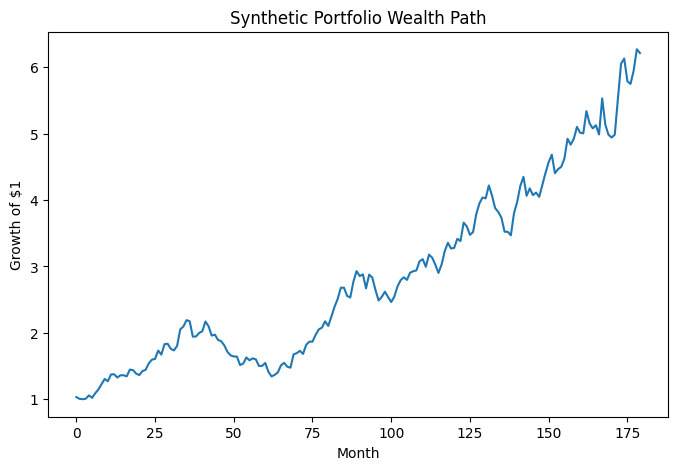

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(wealth.index, wealth.values)
plt.xlabel("Month")
plt.ylabel("Growth of $1")
plt.title("Synthetic Portfolio Wealth Path")
plt.show()

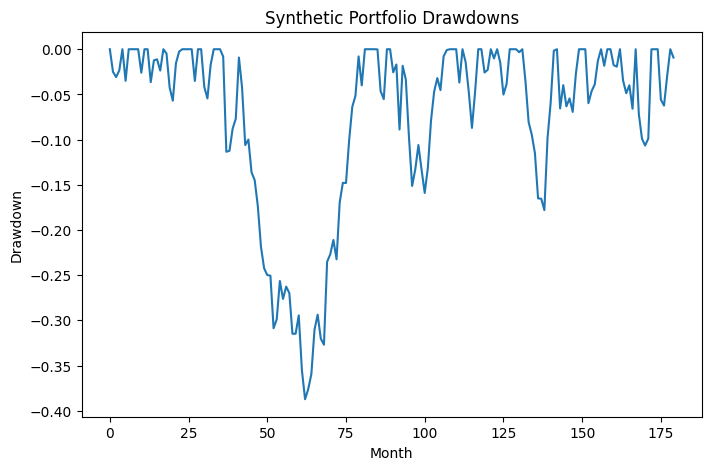

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(drawdown.index, drawdown.values)
plt.xlabel("Month")
plt.ylabel("Drawdown")
plt.title("Synthetic Portfolio Drawdowns")
plt.show()

# Part VII. Final Synthesis

The lecture began with the definition of a return and ended with risk-adjusted performance measurement. The unifying idea is that investment returns are not isolated accounting numbers. They are equilibrium prices of time, risk, inflation, taxes, information, and investor preferences.


## 43. Pulling the Pieces Together

Investment analysis is not just the calculation of historical returns. It is a unified theory of valuation, risk, and choice.

The firm produces profits:

$$
\pi = Pq - C(q)
$$

Investors value those profits:

$$
E_0 = \mathbb{E}[M_1 \pi_1]
$$

The stochastic discount factor comes from intertemporal marginal rates of substitution:

$$
M_1 = \beta \frac{u'(C_1)}{u'(C_0)}
$$

Expected returns satisfy:

$$
1 = \mathbb{E}[M R]
$$

Risk premia are determined by covariance with the stochastic discount factor:

$$
\mathbb{E}[R] - R_f
=
-R_f \operatorname{Cov}(M,R)
$$

The firm’s cost of equity is the expected return investors require to hold the firm’s risky profits.

That cost of equity becomes a hurdle rate for capital budgeting.

Return measurement then tells us how to describe realized investment performance:

$$
R = \frac{D_1}{P_0} + \frac{P_1-P_0}{P_0}
$$

Compounding tells us how returns accumulate through time.

Inflation tells us the difference between nominal and real returns.

Taxes tell us the difference between pre-tax and after-tax returns.

Statistical moments tell us about the shape of the return distribution:

- mean: central tendency,
- variance and standard deviation: dispersion,
- skewness: asymmetry,
- kurtosis: tail thickness.

But the most important risk concept is not volatility by itself. It is whether the asset pays off when investors most value payoffs.

---

## 44. Key Takeaways

1. **Total return equals income return plus capital gain return.**

$$
R = \frac{D_1}{P_0} + \frac{P_1-P_0}{P_0}
$$

2. **Holding-period returns measure actual performance over the investor’s holding period.**

$$
HPR = \frac{P_1 + D_1 - P_0}{P_0}
$$

3. **APR is a quoted rate; EAR is the true annual rate after compounding.**

$$
EAR = \left(1+\frac{APR}{m}\right)^m - 1
$$

4. **Continuous compounding uses the exponential function.**

$$
FV = PV e^{rT}
$$

5. **Real returns adjust nominal returns for inflation.**

$$
1+i = (1+r)(1+\pi)
$$

6. **The Fisher equation links nominal rates, real rates, and expected inflation.**

$$
i \approx r + \mathbb{E}[\pi]
$$

7. **Arithmetic average returns estimate a typical one-period return.**

$$
\bar{R}_A = \frac{1}{T}\sum_{t=1}^T R_t
$$

8. **Geometric average returns measure compound growth.**

$$
\bar{R}_G =
\left[
\prod_{t=1}^T(1+R_t)
\right]^{1/T}
-1
$$

9. **Variance and standard deviation measure dispersion.**

$$
\sigma^2 = \mathbb{E}[(R-\mu)^2]
$$

10. **Skewness and kurtosis describe asymmetry and tail risk.**

$$
\text{Skewness}
=
\mathbb{E}
\left[
\left(
\frac{R-\mu}{\sigma}
\right)^3
\right]
$$

$$
\text{Kurtosis}
=
\mathbb{E}
\left[
\left(
\frac{R-\mu}{\sigma}
\right)^4
\right]
$$

11. **The stochastic discount factor prices assets.**

$$
P = \mathbb{E}[MX]
$$

12. **Expected returns compensate investors for covariance with the SDF.**

$$
\mathbb{E}[R] - R_f
=
-R_f \operatorname{Cov}(M,R)
$$

13. **The firm’s cost of equity is the expected return required by investors.**

14. **That cost of equity becomes the hurdle rate for capital budgeting.**

15. **Taxes reduce returns and alter the value of compounding, income, and capital gains.**